# SomaTrack — Phase 5: Model Evaluation & Interpretation
**Project:** Predicting Study-Related Physical Ailments  

This phase covers:
- Full evaluation on the held-out test set (confusion matrices, classification reports)  
- SHAP-based model interpretation — global feature importance and individual explanations  
- Risk factor identification — top drivers per pain type with actionable insights  
- LIME local explanations for individual student profiles  

---
## Table of Contents
1. [Setup & Model Reconstruction](#1)
2. [Test-Set Evaluation](#2)
3. [SHAP Global Interpretability](#3)
4. [SHAP Per-Target Deep-Dive](#4)
5. [Risk Factor Identification](#5)
6. [LIME Local Explanations](#6)
7. [Actionable Insights Summary](#7)


## 1. Setup & Model Reconstruction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import warnings, json
warnings.filterwarnings('ignore')
shap.initjs()

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb
import lightgbm as lgb

# ── Style ─────────────────────────────────────────────────────────────────────
PAIN_COLORS   = ['#27ae60','#f39c12','#e67e22','#e74c3c']
CLASS_NAMES   = ['None','Mild','Moderate','Chronic']
TARGET_COLORS = {
    'target_back_pain':'#e74c3c',  'target_neck_strain':'#e67e22',
    'target_headache':'#f39c12',   'target_wrist_pain':'#2ecc71',
    'target_eye_strain':'#3498db', 'target_finger_numb':'#9b59b6',
    'target_overall':'#1abc9c',
}
TARGET_NICE = {
    'target_back_pain':'Back Pain',       'target_neck_strain':'Neck Strain',
    'target_headache':'Headache',         'target_wrist_pain':'Wrist Pain',
    'target_eye_strain':'Eye Strain',     'target_finger_numb':'Finger Numb.',
    'target_overall':'Overall Discomfort',
}
FEAT_NICE = {
    'activity_balance':'Activity Balance','posture':'Posture','sitting_hours':'Sitting Hours',
    'digital_load':'Digital Load','exercise_freq':'Exercise Freq.','screen_time':'Screen Time',
    'ergonomic_risk':'Ergonomic Risk','seat_type_ergonomic_office_chair_with_back_support':'Ergonomic Chair',
    'seat_type_bed_floor_no_chair':'Bed/Floor Seat','hydration_index':'Hydration Index',
    'sit_break_ratio':'Sit-Break Ratio','stress_level':'Stress Level',
    'sleep_stress_index':'Sleep-Stress Index','has_back_condition':'Pre-existing Back',
    'max_continuous_sit':'Max Continuous Sit','backpack_weight':'Backpack Weight',
    'sleep_duration':'Sleep Duration','has_wrist_condition':'Pre-existing Wrist',
    'screen_eye_level':'Screen Eye Level','lean_back':'Lean Back',
    'has_neck_condition':'Pre-existing Neck','lighting':'Lighting',
}
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.grid.axis': 'y',
    'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 11, 'axes.labelsize': 10,
})

# ── Load data & metadata ──────────────────────────────────────────────────────
df = pd.read_csv('SomaTrack_FS_Ready.csv')
with open('fs_metadata.json')       as f: meta       = json.load(f)
with open('tuning_scores.json')     as f: tuning     = json.load(f)

FEATURE_COLS = meta['selected_features']
TARGET_COLS  = meta['target_cols']
X = df[FEATURE_COLS].copy()

RANDOM_STATE = 42
TEST_SIZE    = 0.20
CV_FOLDS     = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Friendly feature names for plots
feat_nice_list = [FEAT_NICE.get(f, f.replace('_',' ').title()) for f in FEATURE_COLS]

print(f"Dataset: {df.shape}  |  Features: {len(FEATURE_COLS)}  |  Targets: {len(TARGET_COLS)}")


ModuleNotFoundError: No module named 'shap'

In [ ]:
# ── Best model configurations (from Phase 4 tuning) ──────────────────────────
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

best_configs = {
    'target_back_pain': ('XGB', xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, gamma=0.1,
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1)),

    'target_neck_strain': ('RF', RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=3,
        max_features='sqrt', class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1)),

    'target_headache': ('XGB', xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, gamma=0.0,
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1)),

    'target_wrist_pain': ('RF', RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=3,
        max_features='sqrt', class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1)),

    'target_eye_strain': ('RF', RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=3,
        max_features='log2', class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1)),

    'target_finger_numb': ('LGBM', lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1)),

    'target_overall': ('RF', RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=3,
        max_features='sqrt', class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1)),
}
print("Model configurations defined.")
for t, (name, _) in best_configs.items():
    print(f"  {TARGET_NICE[t]:22s}  →  {name}")


Model configurations defined.
  Back Pain               →  XGB
  Neck Strain             →  RF
  Headache                →  XGB
  Wrist Pain              →  RF
  Eye Strain              →  RF
  Finger Numb.            →  LGBM
  Overall Discomfort      →  RF


In [ ]:
# ── Train-test split — same seed as Phase 4 ──────────────────────────────────
splits = {}
for t in TARGET_COLS:
    y = df[t].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
    # Store as numpy arrays to avoid index-alignment issues downstream
    splits[t] = dict(
        X_train=X_tr.values, X_test=X_te.values,
        y_train=y_tr,        y_test=y_te
    )

# ── Fit all models ────────────────────────────────────────────────────────────
fitted_models = {}
for t in TARGET_COLS:
    name, model = best_configs[t]
    model.fit(splits[t]['X_train'], splits[t]['y_train'])
    fitted_models[t] = model
    print(f"  Fitted {name:6s} for {TARGET_NICE[t]}")

print("\nAll models fitted.")


  Fitted XGB    for Back Pain


  Fitted RF     for Neck Strain


  Fitted XGB    for Headache


  Fitted RF     for Wrist Pain


  Fitted RF     for Eye Strain


  Fitted LGBM   for Finger Numb.


  Fitted RF     for Overall Discomfort

All models fitted.


## 2. Test-Set Evaluation

In [ ]:
test_results = {}
all_reports  = {}

print(f"{'Target':22s}  {'Model':6s}  {'F1_wt':7s}  {'F1_mac':7s}  {'Acc':7s}")
print("-" * 58)

for t in TARGET_COLS:
    model  = fitted_models[t]
    X_te   = splits[t]['X_test']
    y_te   = splits[t]['y_test']
    y_pred = model.predict(X_te)

    f1_wt  = f1_score(y_te, y_pred, average='weighted')
    f1_mac = f1_score(y_te, y_pred, average='macro')
    acc    = accuracy_score(y_te, y_pred)
    name   = best_configs[t][0]

    test_results[t] = {
        'model': name, 'y_test': y_te, 'y_pred': y_pred,
        'f1_wt': round(f1_wt,4), 'f1_mac': round(f1_mac,4), 'acc': round(acc,4)
    }
    all_reports[t] = classification_report(y_te, y_pred, target_names=CLASS_NAMES)
    print(f"  {TARGET_NICE[t]:22s}  {name:6s}  {f1_wt:.4f}  {f1_mac:.4f}  {acc:.4f}")


Target                  Model   F1_wt    F1_mac   Acc    
----------------------------------------------------------
  Back Pain               XGB     0.3709  0.3001  0.3846
  Neck Strain             RF      0.3386  0.3203  0.3419
  Headache                XGB     0.2693  0.2449  0.2778
  Wrist Pain              RF      0.3757  0.3061  0.3974
  Eye Strain              RF      0.3517  0.3293  0.3590


  Finger Numb.            LGBM    0.3840  0.3211  0.3974
  Overall Discomfort      RF      0.6873  0.4315  0.7137


In [ ]:
# ── Classification reports ────────────────────────────────────────────────────
print("=== CLASSIFICATION REPORTS (test set) ===\n")
for t in TARGET_COLS:
    r = test_results[t]
    print(f"{'─'*58}")
    print(f"  {TARGET_NICE[t]}  |  {r['model']}  |  "
          f"F1_wt={r['f1_wt']}  F1_mac={r['f1_mac']}  Acc={r['acc']}")
    print(f"{'─'*58}")
    print(all_reports[t])


=== CLASSIFICATION REPORTS (test set) ===

──────────────────────────────────────────────────────────
  Back Pain  |  XGB  |  F1_wt=0.3709  F1_mac=0.3001  Acc=0.3846
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

        None       0.00      0.00      0.00        20
        Mild       0.30      0.34      0.32        64
    Moderate       0.37      0.42      0.39        72
     Chronic       0.49      0.49      0.49        78

    accuracy                           0.38       234
   macro avg       0.29      0.31      0.30       234
weighted avg       0.36      0.38      0.37       234

──────────────────────────────────────────────────────────
  Neck Strain  |  RF  |  F1_wt=0.3386  F1_mac=0.3203  Acc=0.3419
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

        None       0.25      0.18      0.21        33
        Mild       0.36      0.39      0.38     

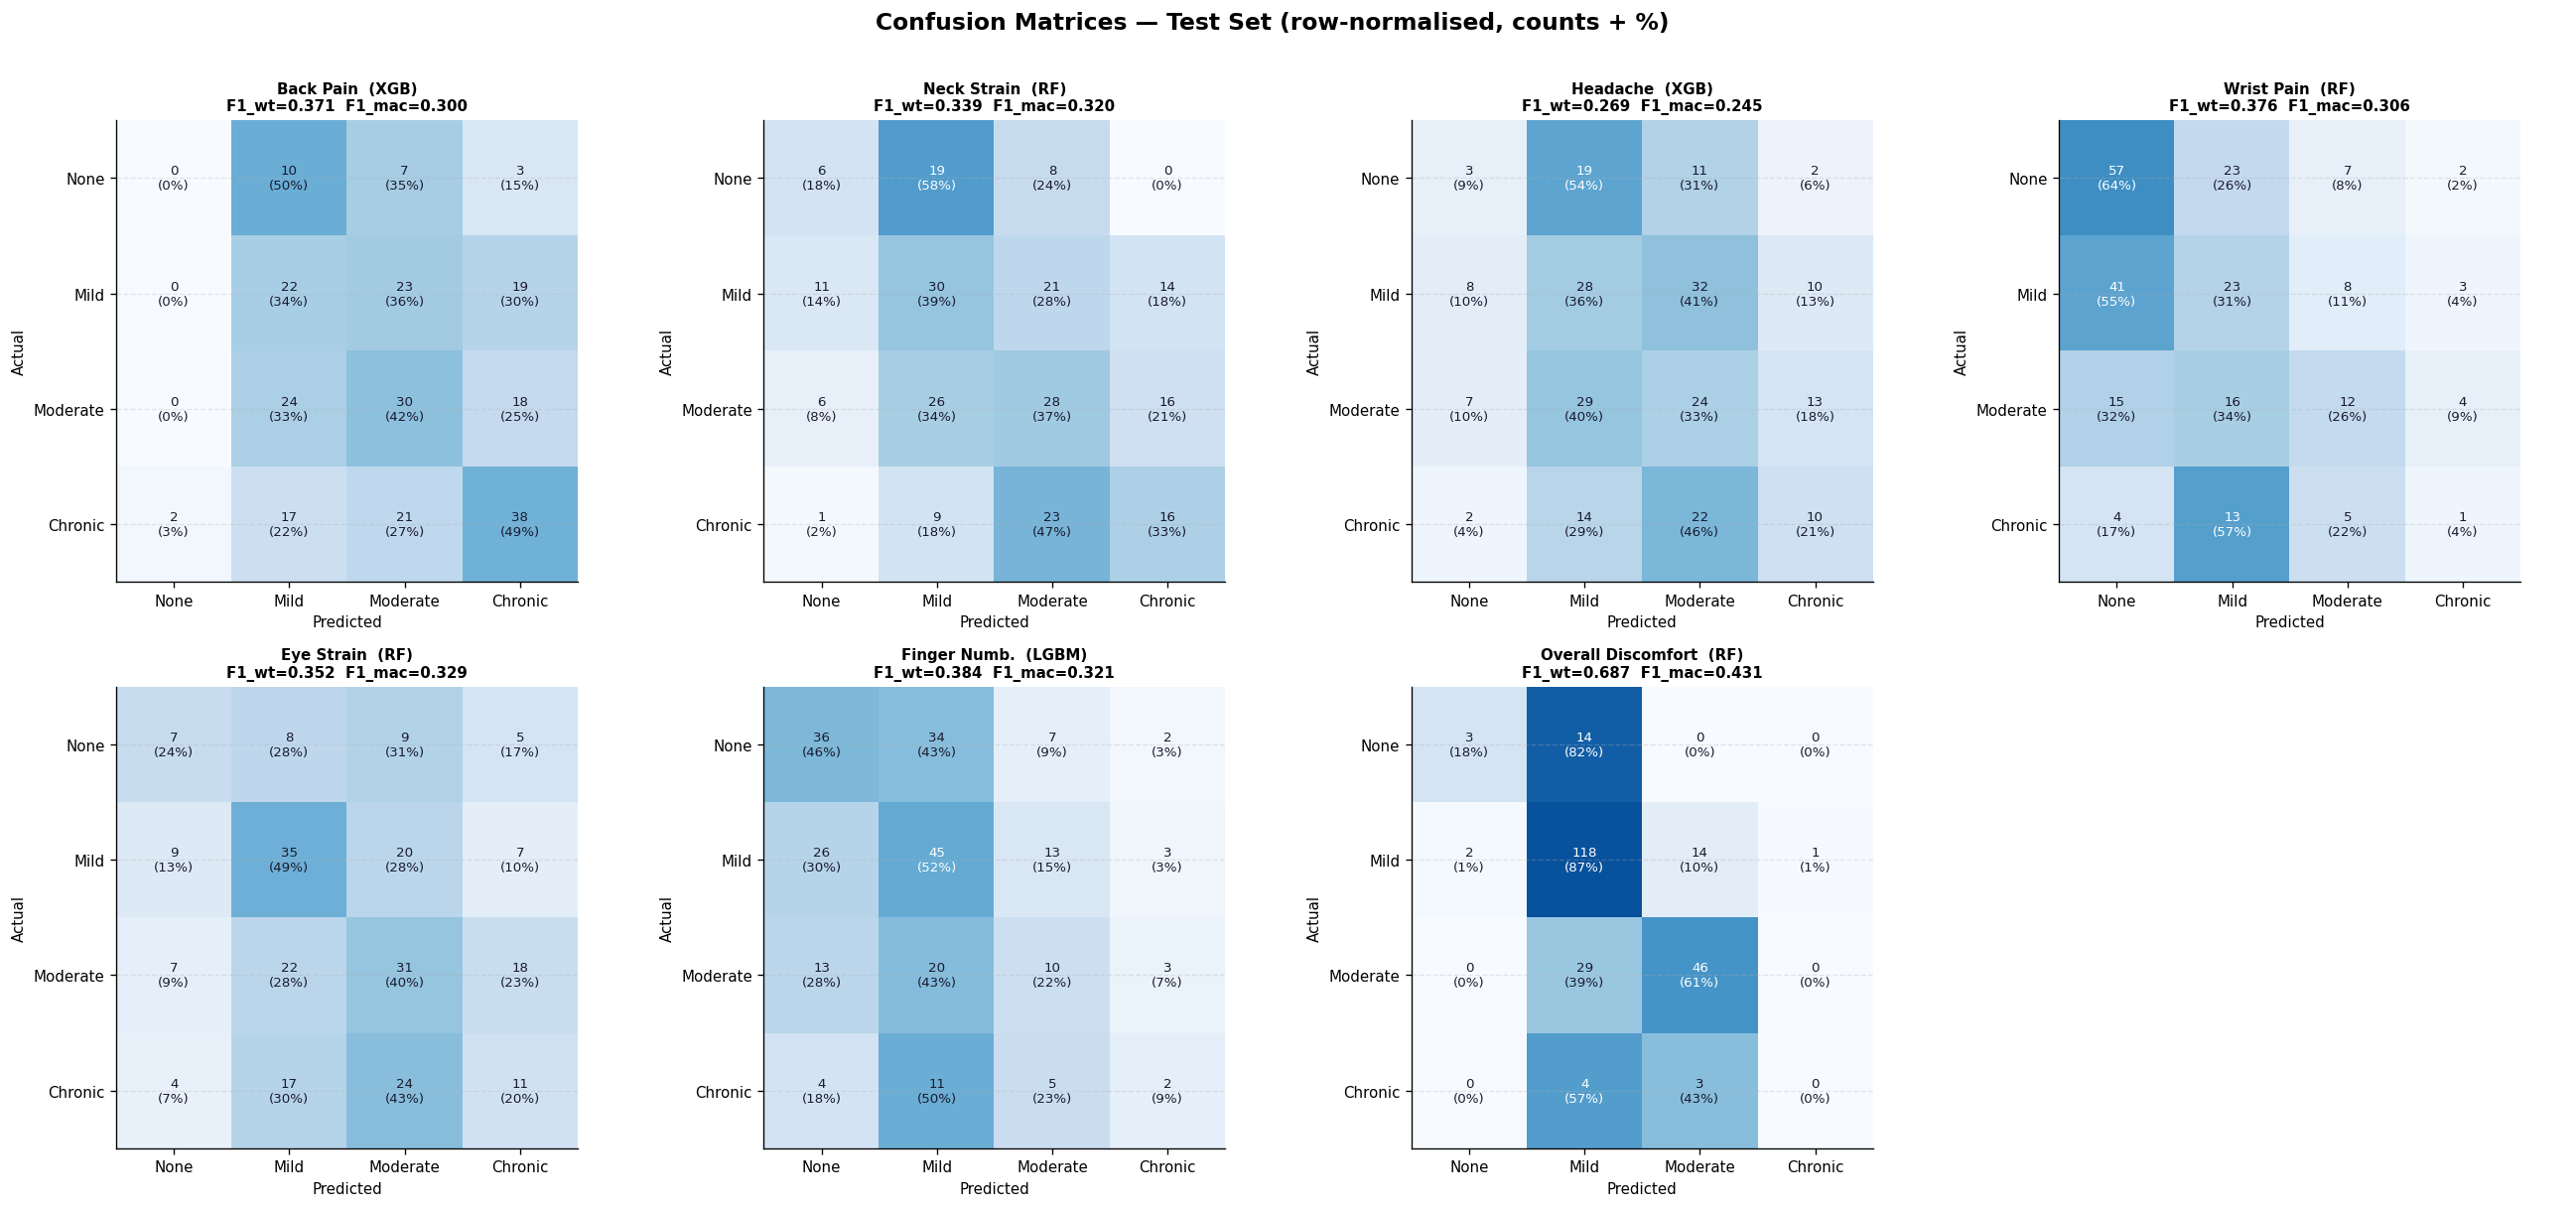

In [ ]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, t in enumerate(TARGET_COLS):
    ax = axes[i]
    cm = confusion_matrix(test_results[t]['y_test'], test_results[t]['y_pred'])

    # Normalise rows for percentage view
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(CLASS_NAMES, fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

    for row in range(4):
        for col in range(4):
            val_abs  = cm[row, col]
            val_pct  = cm_norm[row, col]
            color    = 'white' if val_pct > 0.5 else '#1a1a2e'
            ax.text(col, row, f'{val_abs}\n({val_pct:.0%})',
                    ha='center', va='center', fontsize=8, color=color)

    ax.set_title(
        f"{TARGET_NICE[t]}  ({test_results[t]['model']})\n"
        f"F1_wt={test_results[t]['f1_wt']:.3f}  "
        f"F1_mac={test_results[t]['f1_mac']:.3f}",
        fontweight='bold', fontsize=9)

axes[-1].axis('off')
plt.suptitle('Confusion Matrices — Test Set (row-normalised, counts + %)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


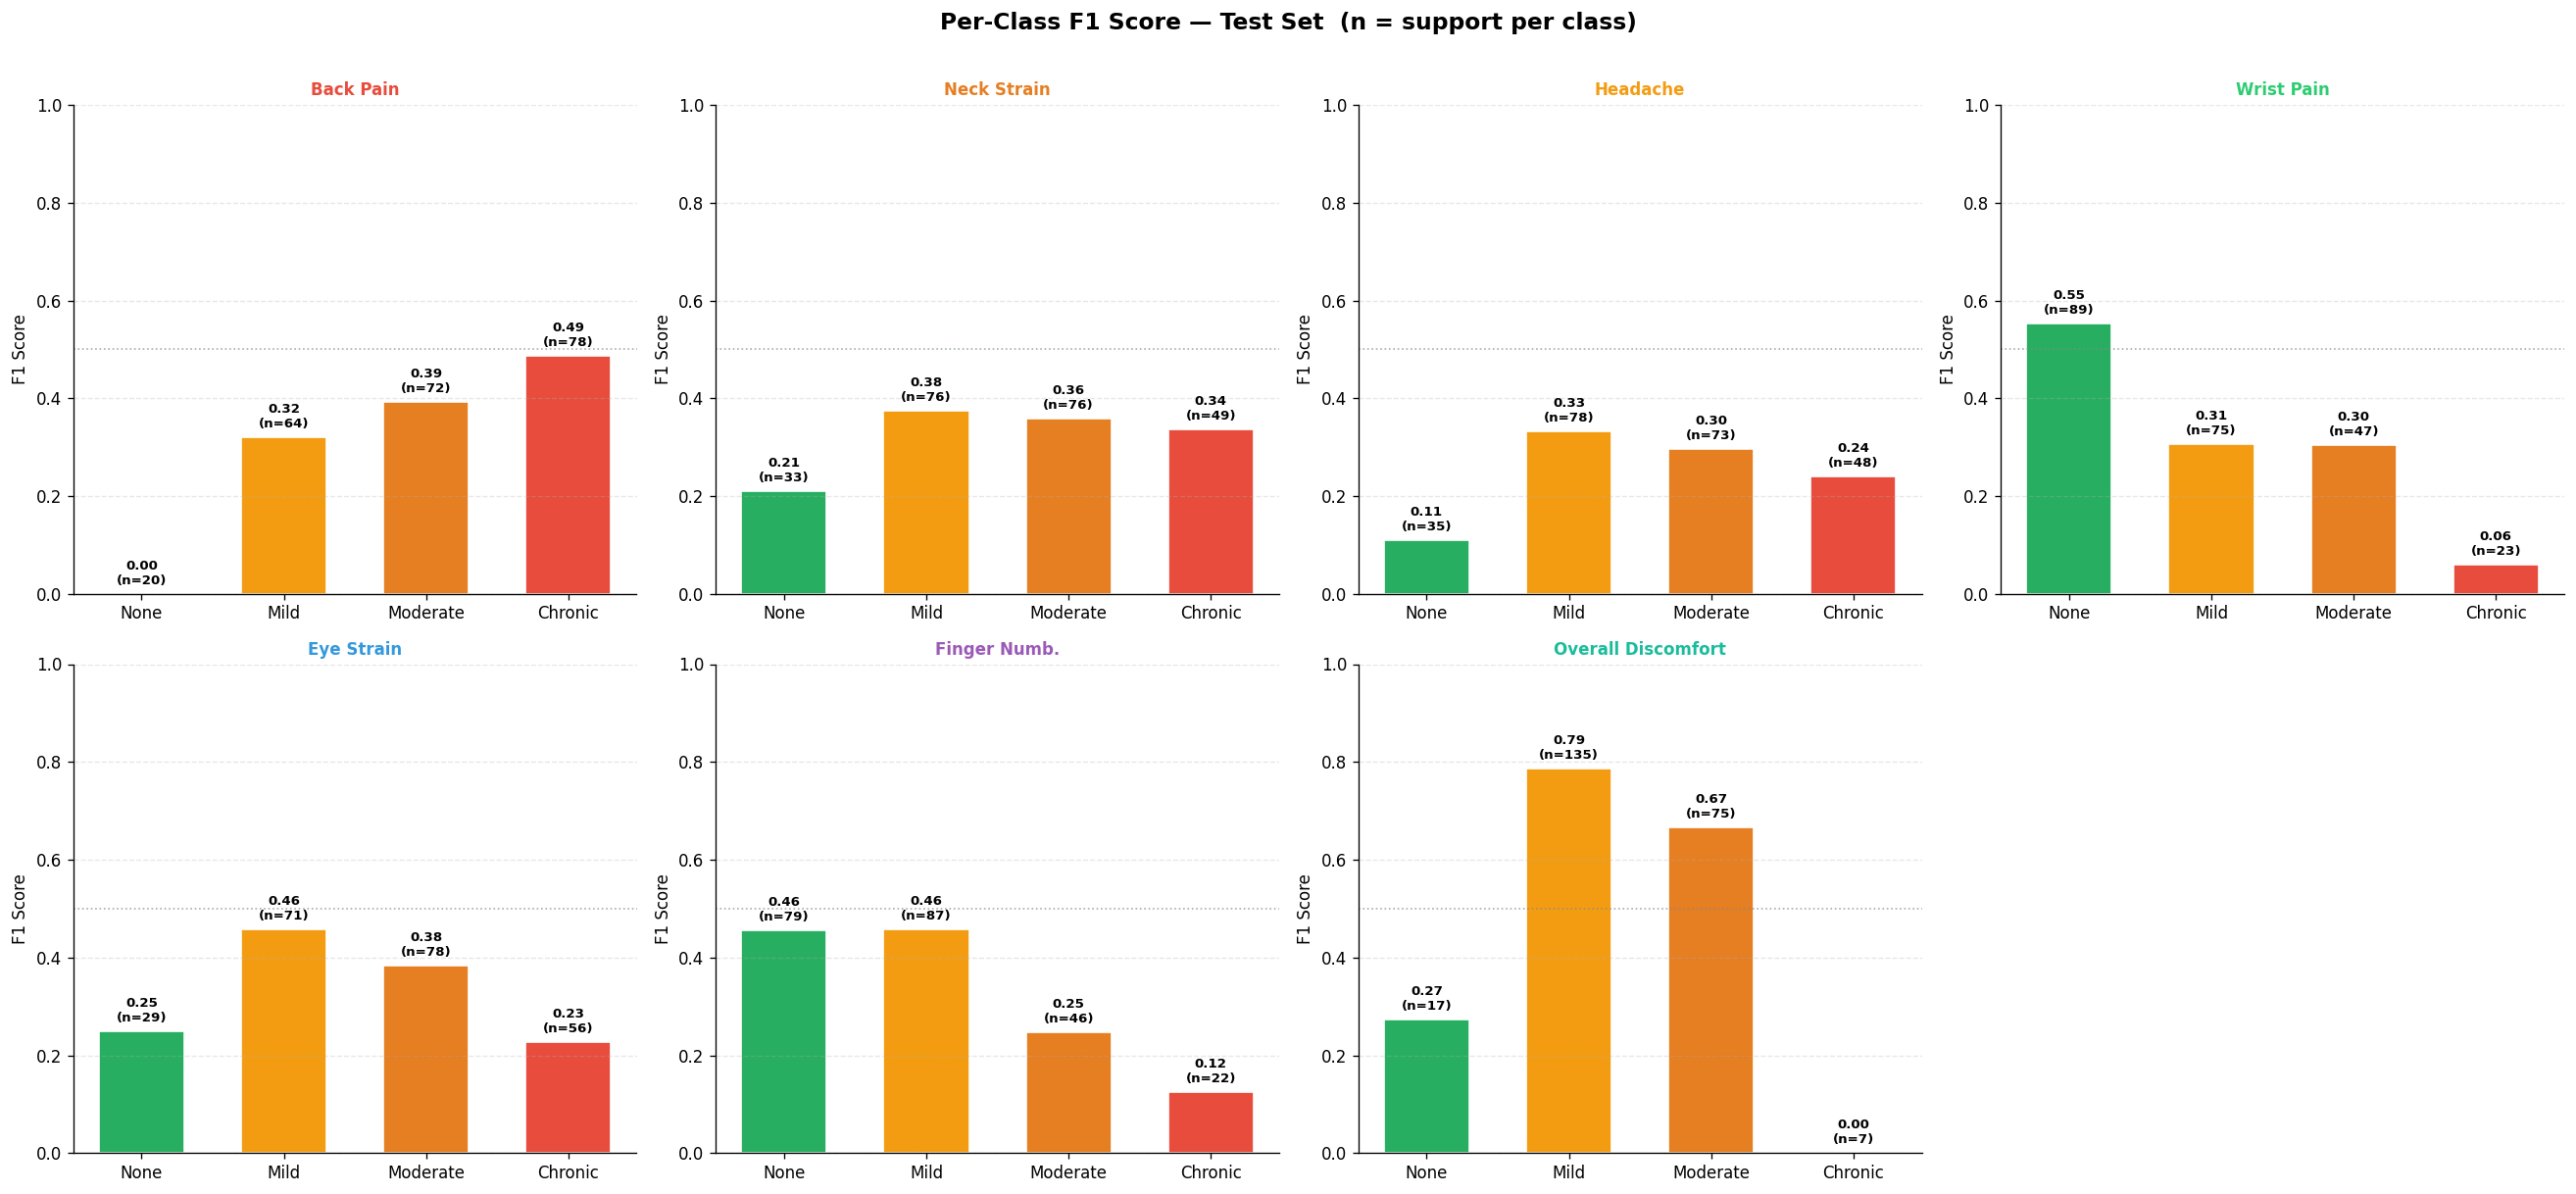

In [ ]:
# ── Per-class F1 breakdown ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, t in enumerate(TARGET_COLS):
    ax    = axes[i]
    y_te  = test_results[t]['y_test']
    y_pr  = test_results[t]['y_pred']

    per_class_f1 = f1_score(y_te, y_pr, average=None, labels=[0,1,2,3],
                             zero_division=0)
    support      = [np.sum(y_te == c) for c in range(4)]

    bars = ax.bar(CLASS_NAMES, per_class_f1,
                  color=PAIN_COLORS, edgecolor='white', width=0.6)
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{TARGET_NICE[t]}", fontweight='bold',
                 color=TARGET_COLORS[t], fontsize=10)
    ax.set_ylabel('F1 Score')
    ax.axhline(0.5, color='#7f8c8d', lw=1, linestyle=':', alpha=0.7)

    for bar, f, s in zip(bars, per_class_f1, support):
        ax.text(bar.get_x()+bar.get_width()/2, f+0.02,
                f'{f:.2f}\n(n={s})',
                ha='center', fontsize=8, fontweight='bold')

axes[-1].axis('off')
plt.suptitle('Per-Class F1 Score — Test Set  (n = support per class)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 3. SHAP Global Interpretability

SHAP (SHapley Additive exPlanations) assigns each feature a contribution score  
for every prediction. We compute SHAP values on the **full dataset** using  
`TreeExplainer` (exact, fast for RF/XGB/LGBM).  

For multiclass, we aggregate across classes using **mean absolute SHAP**.


In [ ]:
# ── Compute SHAP values for all models ───────────────────────────────────────
# Note: TreeExplainer returns a 3D array (n_samples, n_features, n_classes)
# for multiclass RF/XGB/LGBM
shap_values_dict = {}

for t in TARGET_COLS:
    model     = fitted_models[t]
    name      = best_configs[t][0]
    explainer = shap.TreeExplainer(model)
    sv        = explainer.shap_values(X)   # shape: (n_samples, n_features, n_classes)

    # Normalise to 3D — some versions may still return list
    if isinstance(sv, list):
        sv = np.stack(sv, axis=2)          # → (n_samples, n_features, n_classes)

    # Mean absolute SHAP across all classes → (n_samples, n_features)
    sv_abs_mean = np.abs(sv).mean(axis=2)

    shap_values_dict[t] = {
        'raw':       sv,                   # (n_samples, n_features, n_classes)
        'abs_mean':  sv_abs_mean,          # (n_samples, n_features)
        'explainer': explainer,
    }
    print(f"  SHAP computed: {TARGET_NICE[t]:22s} ({name})  sv.shape={sv.shape}")

print("\nSHAP computation complete.")


  SHAP computed: Back Pain              (XGB)  sv.shape=(1170, 22, 4)


  SHAP computed: Neck Strain            (RF)  sv.shape=(1170, 22, 4)


  SHAP computed: Headache               (XGB)  sv.shape=(1170, 22, 4)


  SHAP computed: Wrist Pain             (RF)  sv.shape=(1170, 22, 4)


  SHAP computed: Eye Strain             (RF)  sv.shape=(1170, 22, 4)


  SHAP computed: Finger Numb.           (LGBM)  sv.shape=(1170, 22, 4)


  SHAP computed: Overall Discomfort     (RF)  sv.shape=(1170, 22, 4)

SHAP computation complete.


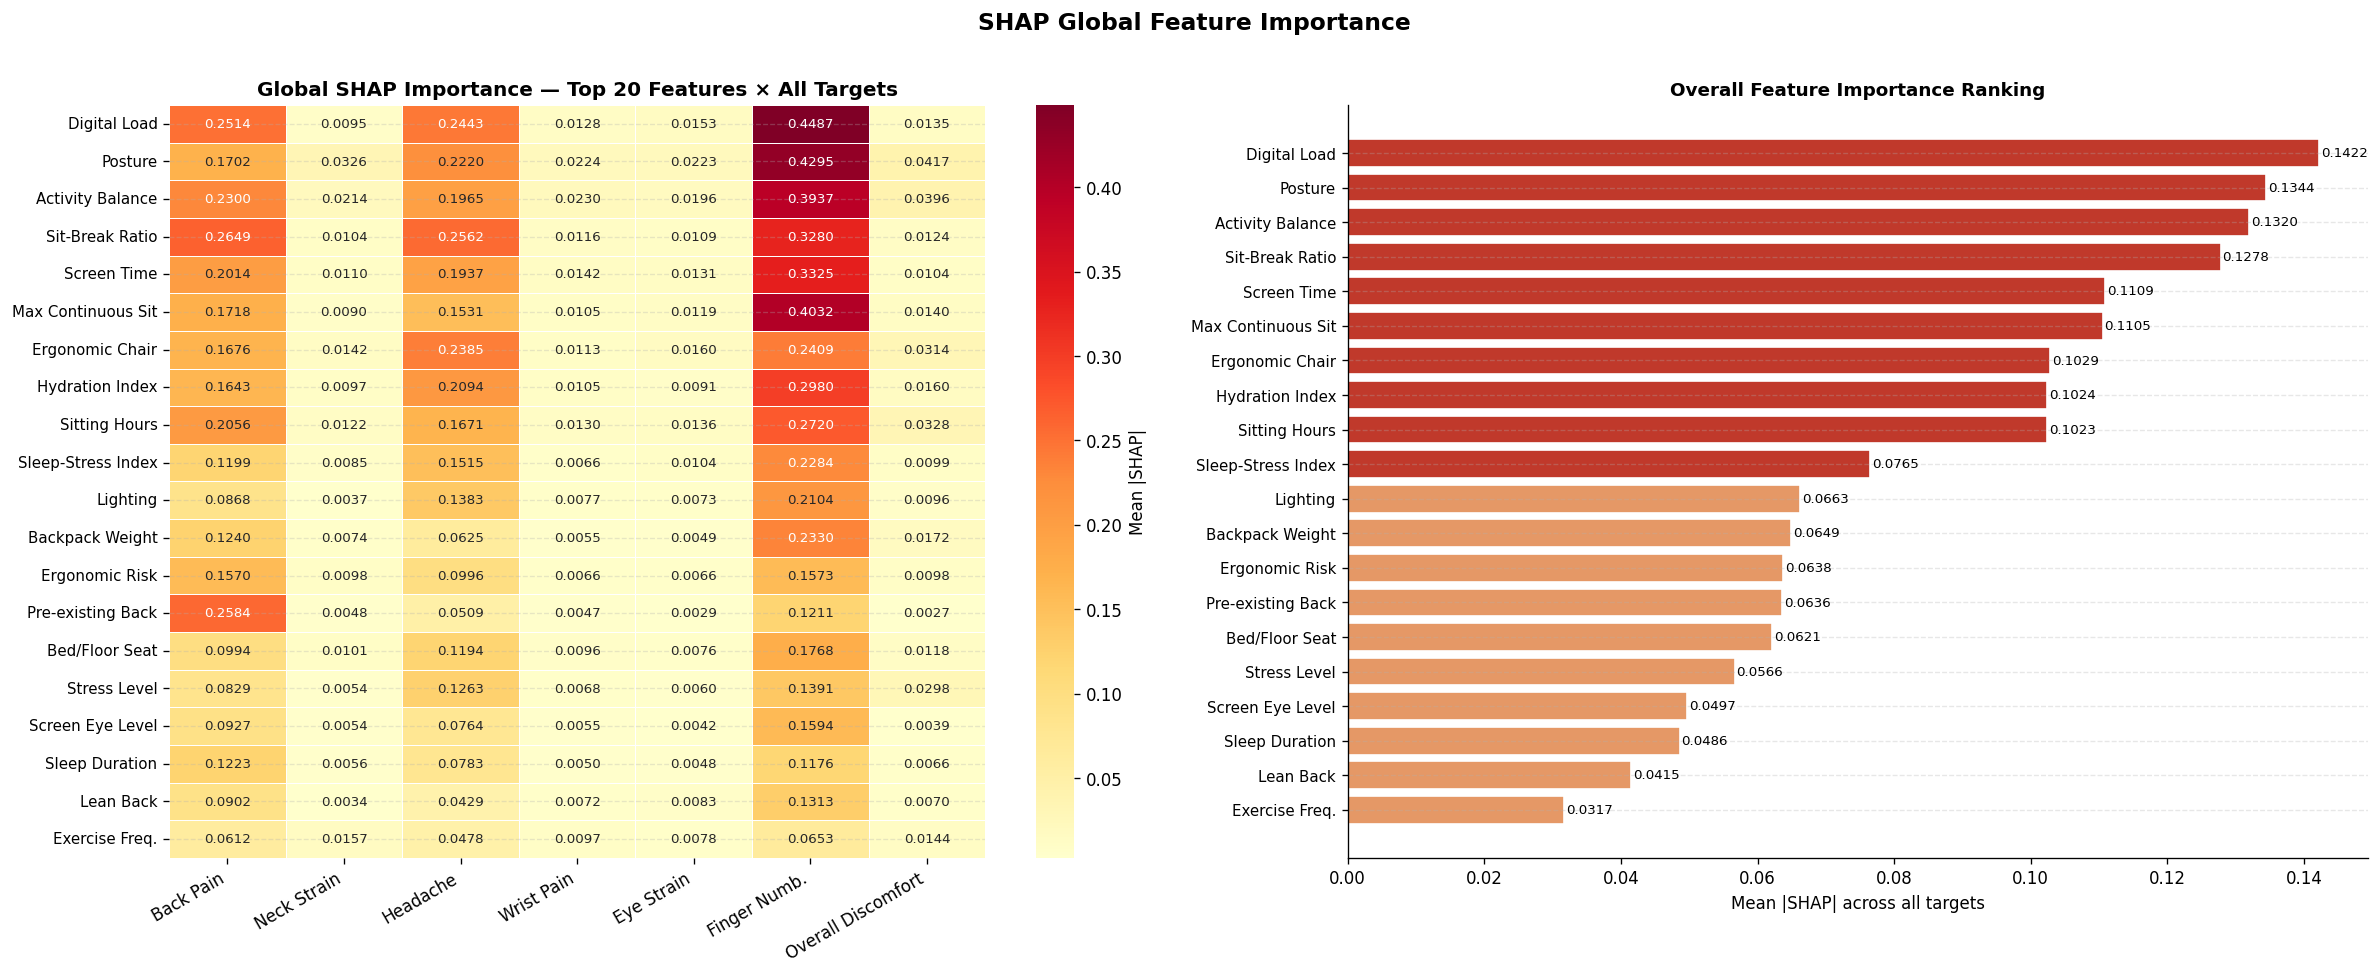

In [ ]:
# ── Global SHAP importance: mean |SHAP| per feature across all targets ────────
global_shap = pd.DataFrame({
    t: shap_values_dict[t]['abs_mean'].mean(axis=0)   # (n_features,)
    for t in TARGET_COLS
}, index=feat_nice_list)                               # (n_features, n_targets)

global_shap['Mean'] = global_shap.mean(axis=1)
global_shap = global_shap.sort_values('Mean', ascending=False)

# Rename target columns to nice names
rename_map = {t: TARGET_NICE[t] for t in TARGET_COLS}
global_shap = global_shap.rename(columns=rename_map)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: heatmap feature × target (top 20)
target_cols_nice = [TARGET_NICE[t] for t in TARGET_COLS]
sns.heatmap(
    global_shap[target_cols_nice].head(20),
    annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.4, ax=axes[0], annot_kws={'size': 8},
    cbar_kws={'label': 'Mean |SHAP|'})
axes[0].set_title('Global SHAP Importance — Top 20 Features × All Targets',
                   fontweight='bold', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)

# Right: mean across targets bar
mean_shap = global_shap['Mean'].head(20).sort_values()
colors_bar = ['#c0392b' if v > mean_shap.median() else '#e59866' for v in mean_shap.values]
axes[1].barh(range(len(mean_shap)), mean_shap.values, color=colors_bar, edgecolor='white')
axes[1].set_yticks(range(len(mean_shap)))
axes[1].set_yticklabels(mean_shap.index, fontsize=9)
axes[1].set_xlabel('Mean |SHAP| across all targets')
axes[1].set_title('Overall Feature Importance Ranking', fontweight='bold')
for j, v in enumerate(mean_shap.values):
    axes[1].text(v + 0.0003, j, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('SHAP Global Feature Importance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


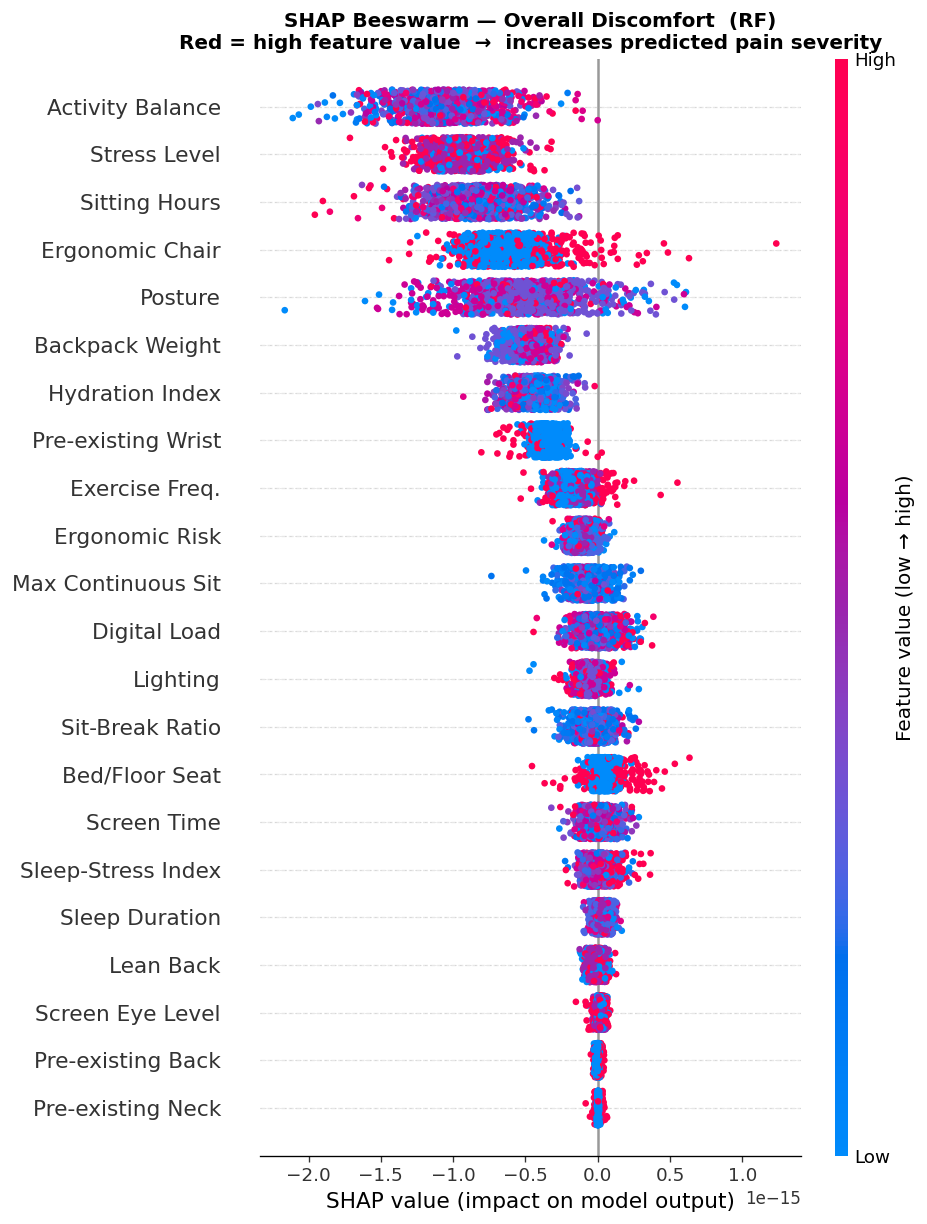

In [ ]:
# ── SHAP summary beeswarm — overall discomfort ───────────────────────────────
t_ov   = 'target_overall'
sv_ov  = shap_values_dict[t_ov]['raw']      # (n_samples, n_features, n_classes)
name_ov = best_configs[t_ov][0]

# Aggregate across classes: sum SHAP values → (n_samples, n_features)
sv_agg = sv_ov.sum(axis=2)

X_display = X.copy()
X_display.columns = feat_nice_list

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(sv_agg, X_display, plot_type='dot',
                  max_display=22, show=False,
                  color_bar_label='Feature value (low → high)')
plt.gca().set_title(
    f'SHAP Beeswarm — Overall Discomfort  ({name_ov})\n'
    'Red = high feature value  →  increases predicted pain severity',
    fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


## 4. SHAP Per-Target Deep-Dive

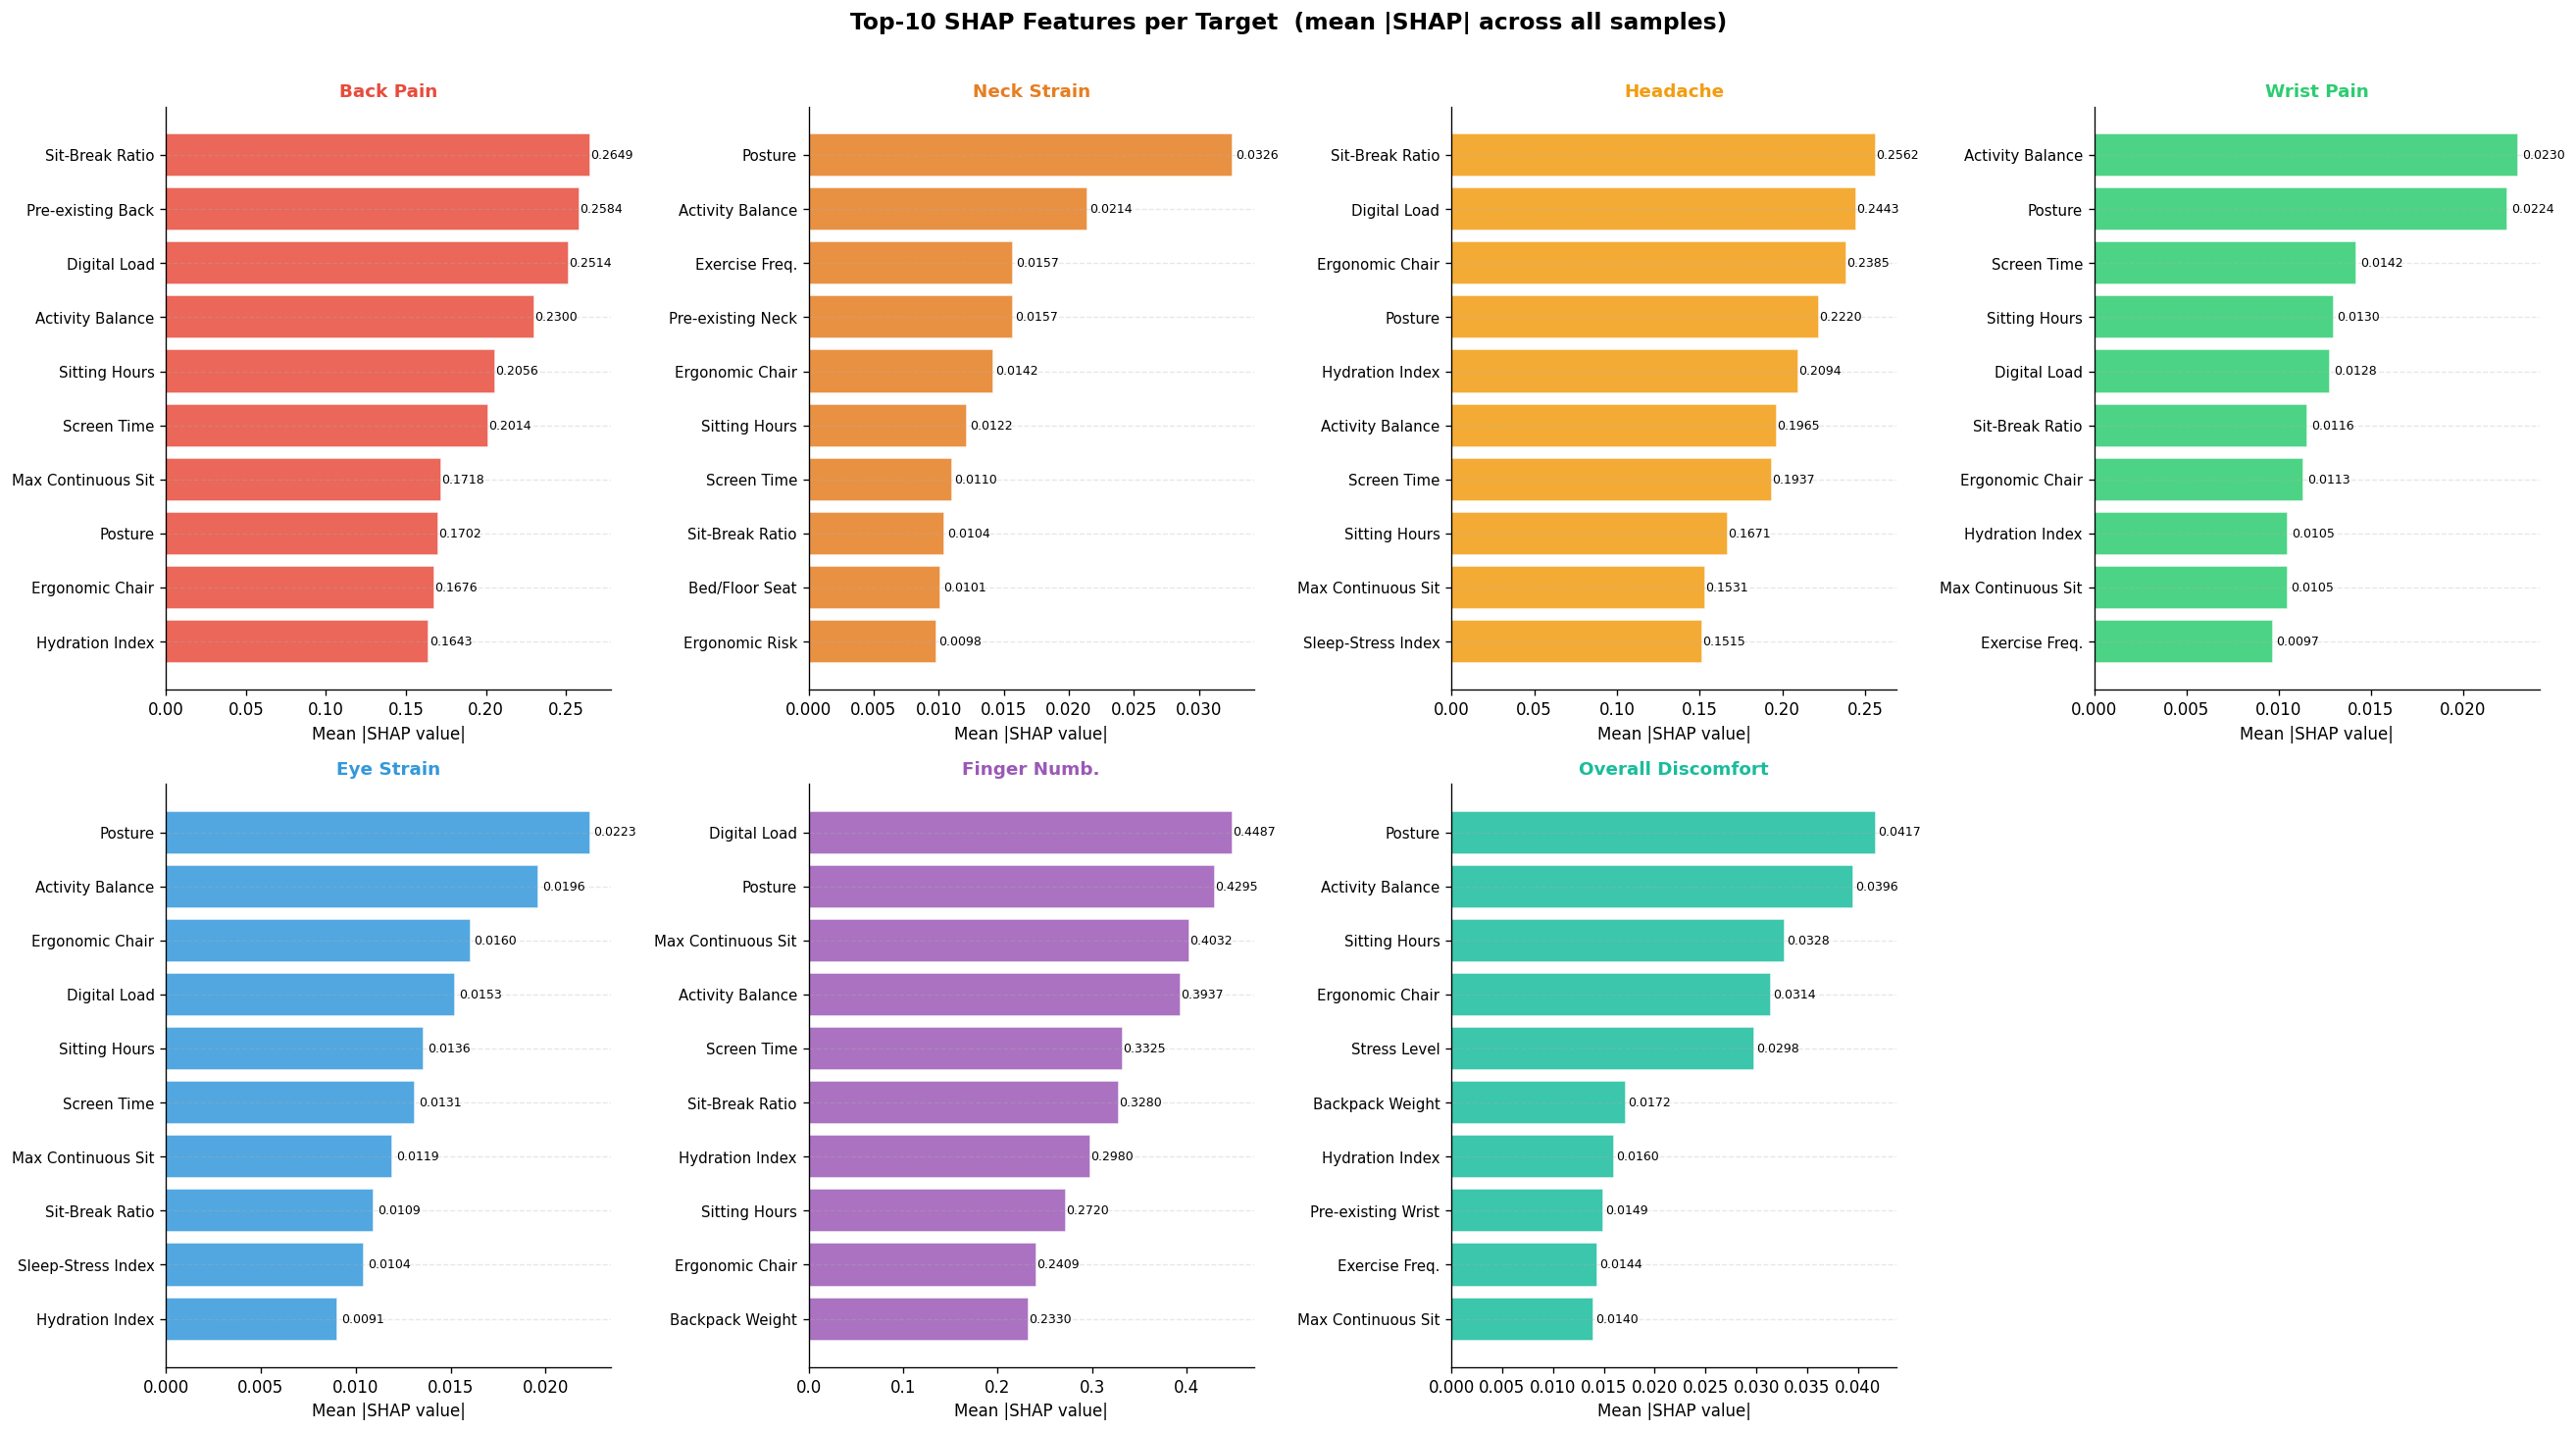

In [ ]:
# ── Top-10 SHAP features per target — bar charts ────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

for i, t in enumerate(TARGET_COLS):
    ax     = axes[i]
    sv_abs = shap_values_dict[t]['abs_mean']         # [n_samples, n_features]
    mean_abs = pd.Series(sv_abs.mean(axis=0), index=feat_nice_list)
    top10    = mean_abs.sort_values(ascending=False).head(10)
    top10_plot = top10.sort_values(ascending=True)

    c = TARGET_COLORS[t]
    ax.barh(range(len(top10_plot)), top10_plot.values,
            color=c, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(top10_plot)))
    ax.set_yticklabels(top10_plot.index, fontsize=9)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(TARGET_NICE[t], fontweight='bold', color=c, fontsize=11)
    for j, v in enumerate(top10_plot.values):
        ax.text(v + 0.0002, j, f'{v:.4f}', va='center', fontsize=7.5)

axes[-1].axis('off')
plt.suptitle('Top-10 SHAP Features per Target  (mean |SHAP| across all samples)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


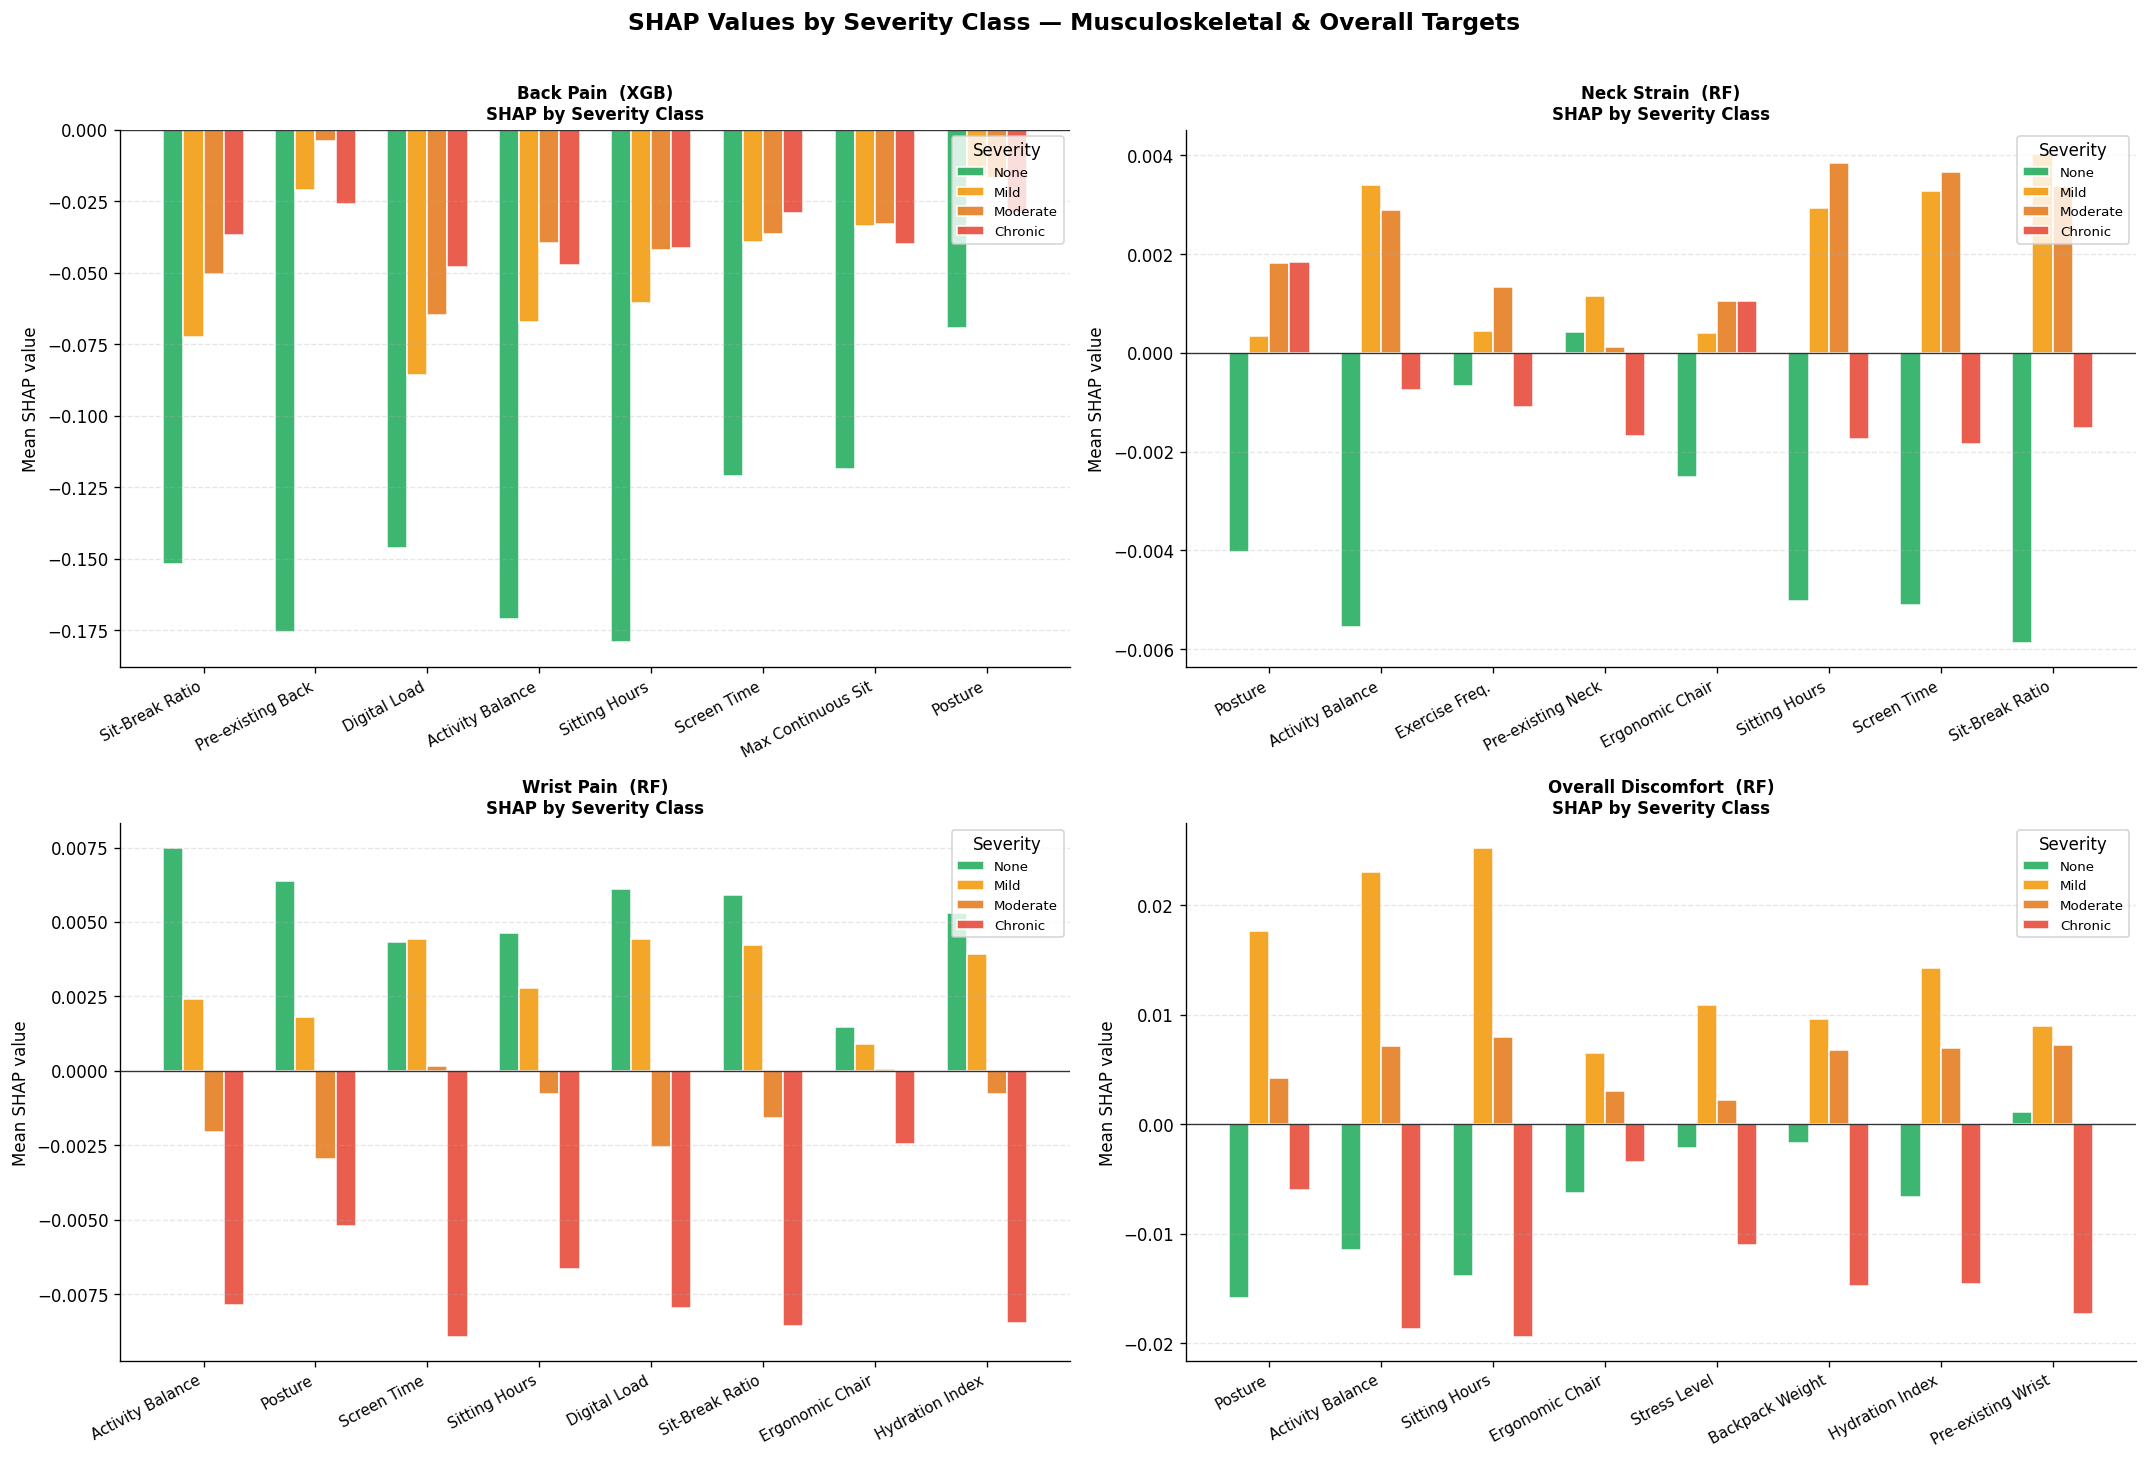

In [ ]:
# ── SHAP class-level breakdown for musculoskeletal + overall targets ──────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

msk_targets = ['target_back_pain','target_neck_strain',
               'target_wrist_pain','target_overall']

for ax_i, t in enumerate(msk_targets):
    ax   = axes[ax_i]
    sv   = shap_values_dict[t]['raw']        # (n_samples, n_features, n_classes)
    name = best_configs[t][0]
    n_classes = sv.shape[2]

    # Top 8 features by mean abs SHAP
    sv_abs_mean = shap_values_dict[t]['abs_mean'].mean(axis=0)
    top8_idx    = np.argsort(sv_abs_mean)[::-1][:8]
    top8_names  = [feat_nice_list[j] for j in top8_idx]

    x = np.arange(len(top8_names))
    w = 0.18
    for c in range(min(n_classes, 4)):
        class_sv   = sv[:, top8_idx, c]     # (n_samples, 8)
        class_mean = class_sv.mean(axis=0)  # (8,)
        offset = (c - 1.5) * w
        ax.bar(x + offset, class_mean, width=w,
               color=PAIN_COLORS[c], edgecolor='white',
               alpha=0.9, label=CLASS_NAMES[c])

    ax.set_xticks(x)
    ax.set_xticklabels(top8_names, rotation=28, ha='right', fontsize=9)
    ax.axhline(0, color='#333', lw=0.8)
    ax.set_ylabel('Mean SHAP value')
    ax.set_title(f'{TARGET_NICE[t]}  ({name})\nSHAP by Severity Class',
                 fontweight='bold', fontsize=10)
    ax.legend(title='Severity', fontsize=8, loc='upper right')

plt.suptitle('SHAP Values by Severity Class — Musculoskeletal & Overall Targets',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


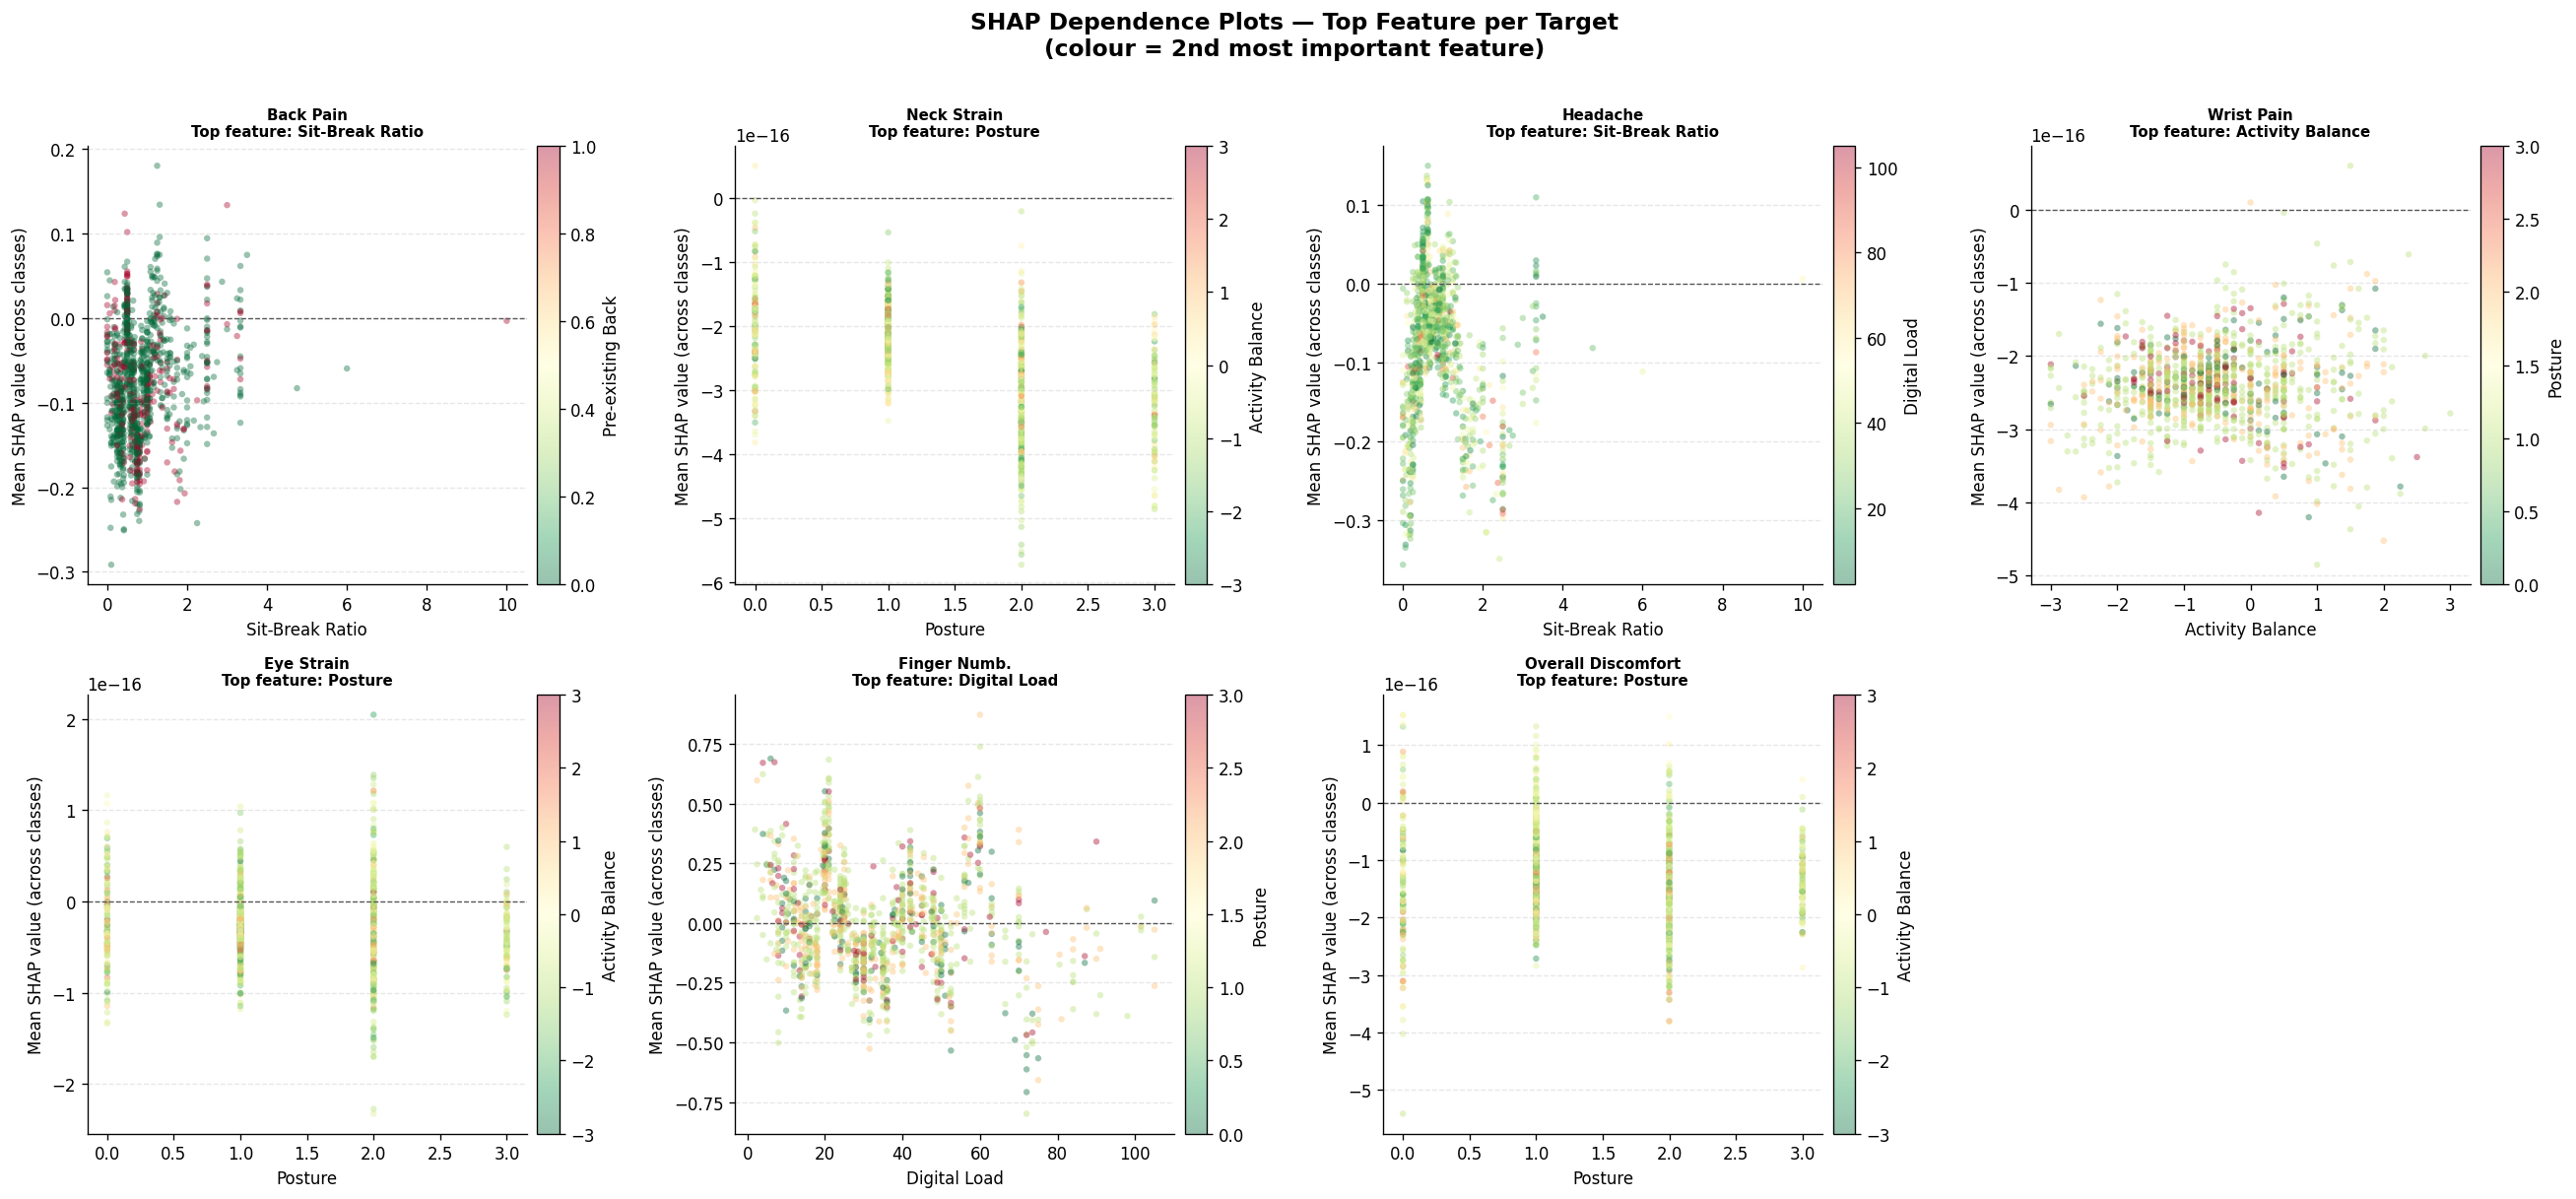

In [ ]:
# ── SHAP dependence plots — top feature per target ───────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, t in enumerate(TARGET_COLS):
    ax   = axes[i]
    sv   = shap_values_dict[t]['raw']        # (n_samples, n_features, n_classes)
    sv_abs = shap_values_dict[t]['abs_mean'] # (n_samples, n_features)

    # Top 2 features by mean |SHAP|
    mean_abs     = sv_abs.mean(axis=0)
    top2_idx     = np.argsort(mean_abs)[::-1][:2]
    top_feat_idx = top2_idx[0]
    sec_feat_idx = top2_idx[1]

    top_feat_name = feat_nice_list[top_feat_idx]
    top_feat_vals = X.iloc[:, top_feat_idx].values
    sec_feat_vals = X.iloc[:, sec_feat_idx].values

    # Aggregate SHAP across classes for top feature
    shap_for_feat = sv[:, top_feat_idx, :].mean(axis=1)  # (n_samples,)

    sc = ax.scatter(top_feat_vals, shap_for_feat,
                    c=sec_feat_vals, cmap='RdYlGn_r',
                    alpha=0.4, s=15, linewidths=0)
    plt.colorbar(sc, ax=ax, label=feat_nice_list[sec_feat_idx], pad=0.02)
    ax.axhline(0, color='#555', lw=0.8, linestyle='--')
    ax.set_xlabel(top_feat_name)
    ax.set_ylabel('Mean SHAP value (across classes)')
    ax.set_title(f'{TARGET_NICE[t]}\nTop feature: {top_feat_name}',
                 fontweight='bold', fontsize=9)

axes[-1].axis('off')
plt.suptitle('SHAP Dependence Plots — Top Feature per Target\n'
             '(colour = 2nd most important feature)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5. Risk Factor Identification

We combine SHAP importance with feature value direction to identify the  
**top modifiable risk factors** per pain type — i.e., features where  
high values push predictions toward Moderate/Chronic (classes 2–3).


In [ ]:
# ── Risk direction: features pushing toward high-severity classes (2 & 3) ────
risk_factors = {}

for t in TARGET_COLS:
    sv       = shap_values_dict[t]['raw']       # (n_samples, n_features, n_classes)
    sv_abs   = shap_values_dict[t]['abs_mean']  # (n_samples, n_features)

    # Importance toward classes 2 (Moderate) and 3 (Chronic)
    shap_high = (np.abs(sv[:, :, 2]) + np.abs(sv[:, :, 3])) / 2  # (n_samples, n_features)
    mean_importance = shap_high.mean(axis=0)
    top_idx = np.argsort(mean_importance)[::-1][:5]

    factors = []
    for idx in top_idx:
        feat_name  = FEATURE_COLS[idx]
        feat_nice  = feat_nice_list[idx]
        importance = mean_importance[idx]
        feat_vals  = X.iloc[:, idx].values

        # Direction: does high feature value → positive SHAP for class 2+3?
        shap_sign = (sv[:, idx, 2] + sv[:, idx, 3]) / 2
        corr      = np.corrcoef(feat_vals, shap_sign)[0, 1]
        direction = 'increases risk' if corr > 0 else 'decreases risk'
        modifiable = feat_name not in ['has_back_condition','has_neck_condition',
                                        'has_wrist_condition']
        factors.append({
            'feature':     feat_nice,
            'importance':  round(importance, 5),
            'direction':   direction,
            'modifiable':  modifiable,
            'correlation': round(corr, 3),
        })
    risk_factors[t] = factors

print("=== TOP 5 RISK FACTORS PER TARGET ===\n")
for t, factors in risk_factors.items():
    print(f"  {TARGET_NICE[t]}:")
    for rank, f in enumerate(factors, 1):
        mod = '✓ modifiable' if f['modifiable'] else '✗ fixed'
        print(f"    {rank}. {f['feature']:30s}  {f['direction']:20s}  "
              f"SHAP={f['importance']:.5f}  [{mod}]")
    print()


=== TOP 5 RISK FACTORS PER TARGET ===

  Back Pain:
    1. Sit-Break Ratio                 increases risk        SHAP=0.24515  [✓ modifiable]
    2. Digital Load                    decreases risk        SHAP=0.21258  [✓ modifiable]
    3. Pre-existing Back               increases risk        SHAP=0.19099  [✗ fixed]
    4. Activity Balance                decreases risk        SHAP=0.18659  [✓ modifiable]
    5. Screen Time                     increases risk        SHAP=0.17768  [✓ modifiable]

  Neck Strain:
    1. Posture                         increases risk        SHAP=0.03210  [✓ modifiable]
    2. Activity Balance                decreases risk        SHAP=0.02147  [✓ modifiable]
    3. Pre-existing Neck               increases risk        SHAP=0.01730  [✗ fixed]
    4. Exercise Freq.                  decreases risk        SHAP=0.01612  [✓ modifiable]
    5. Bed/Floor Seat                  increases risk        SHAP=0.01264  [✓ modifiable]

  Headache:
    1. Sit-Break Ratio       

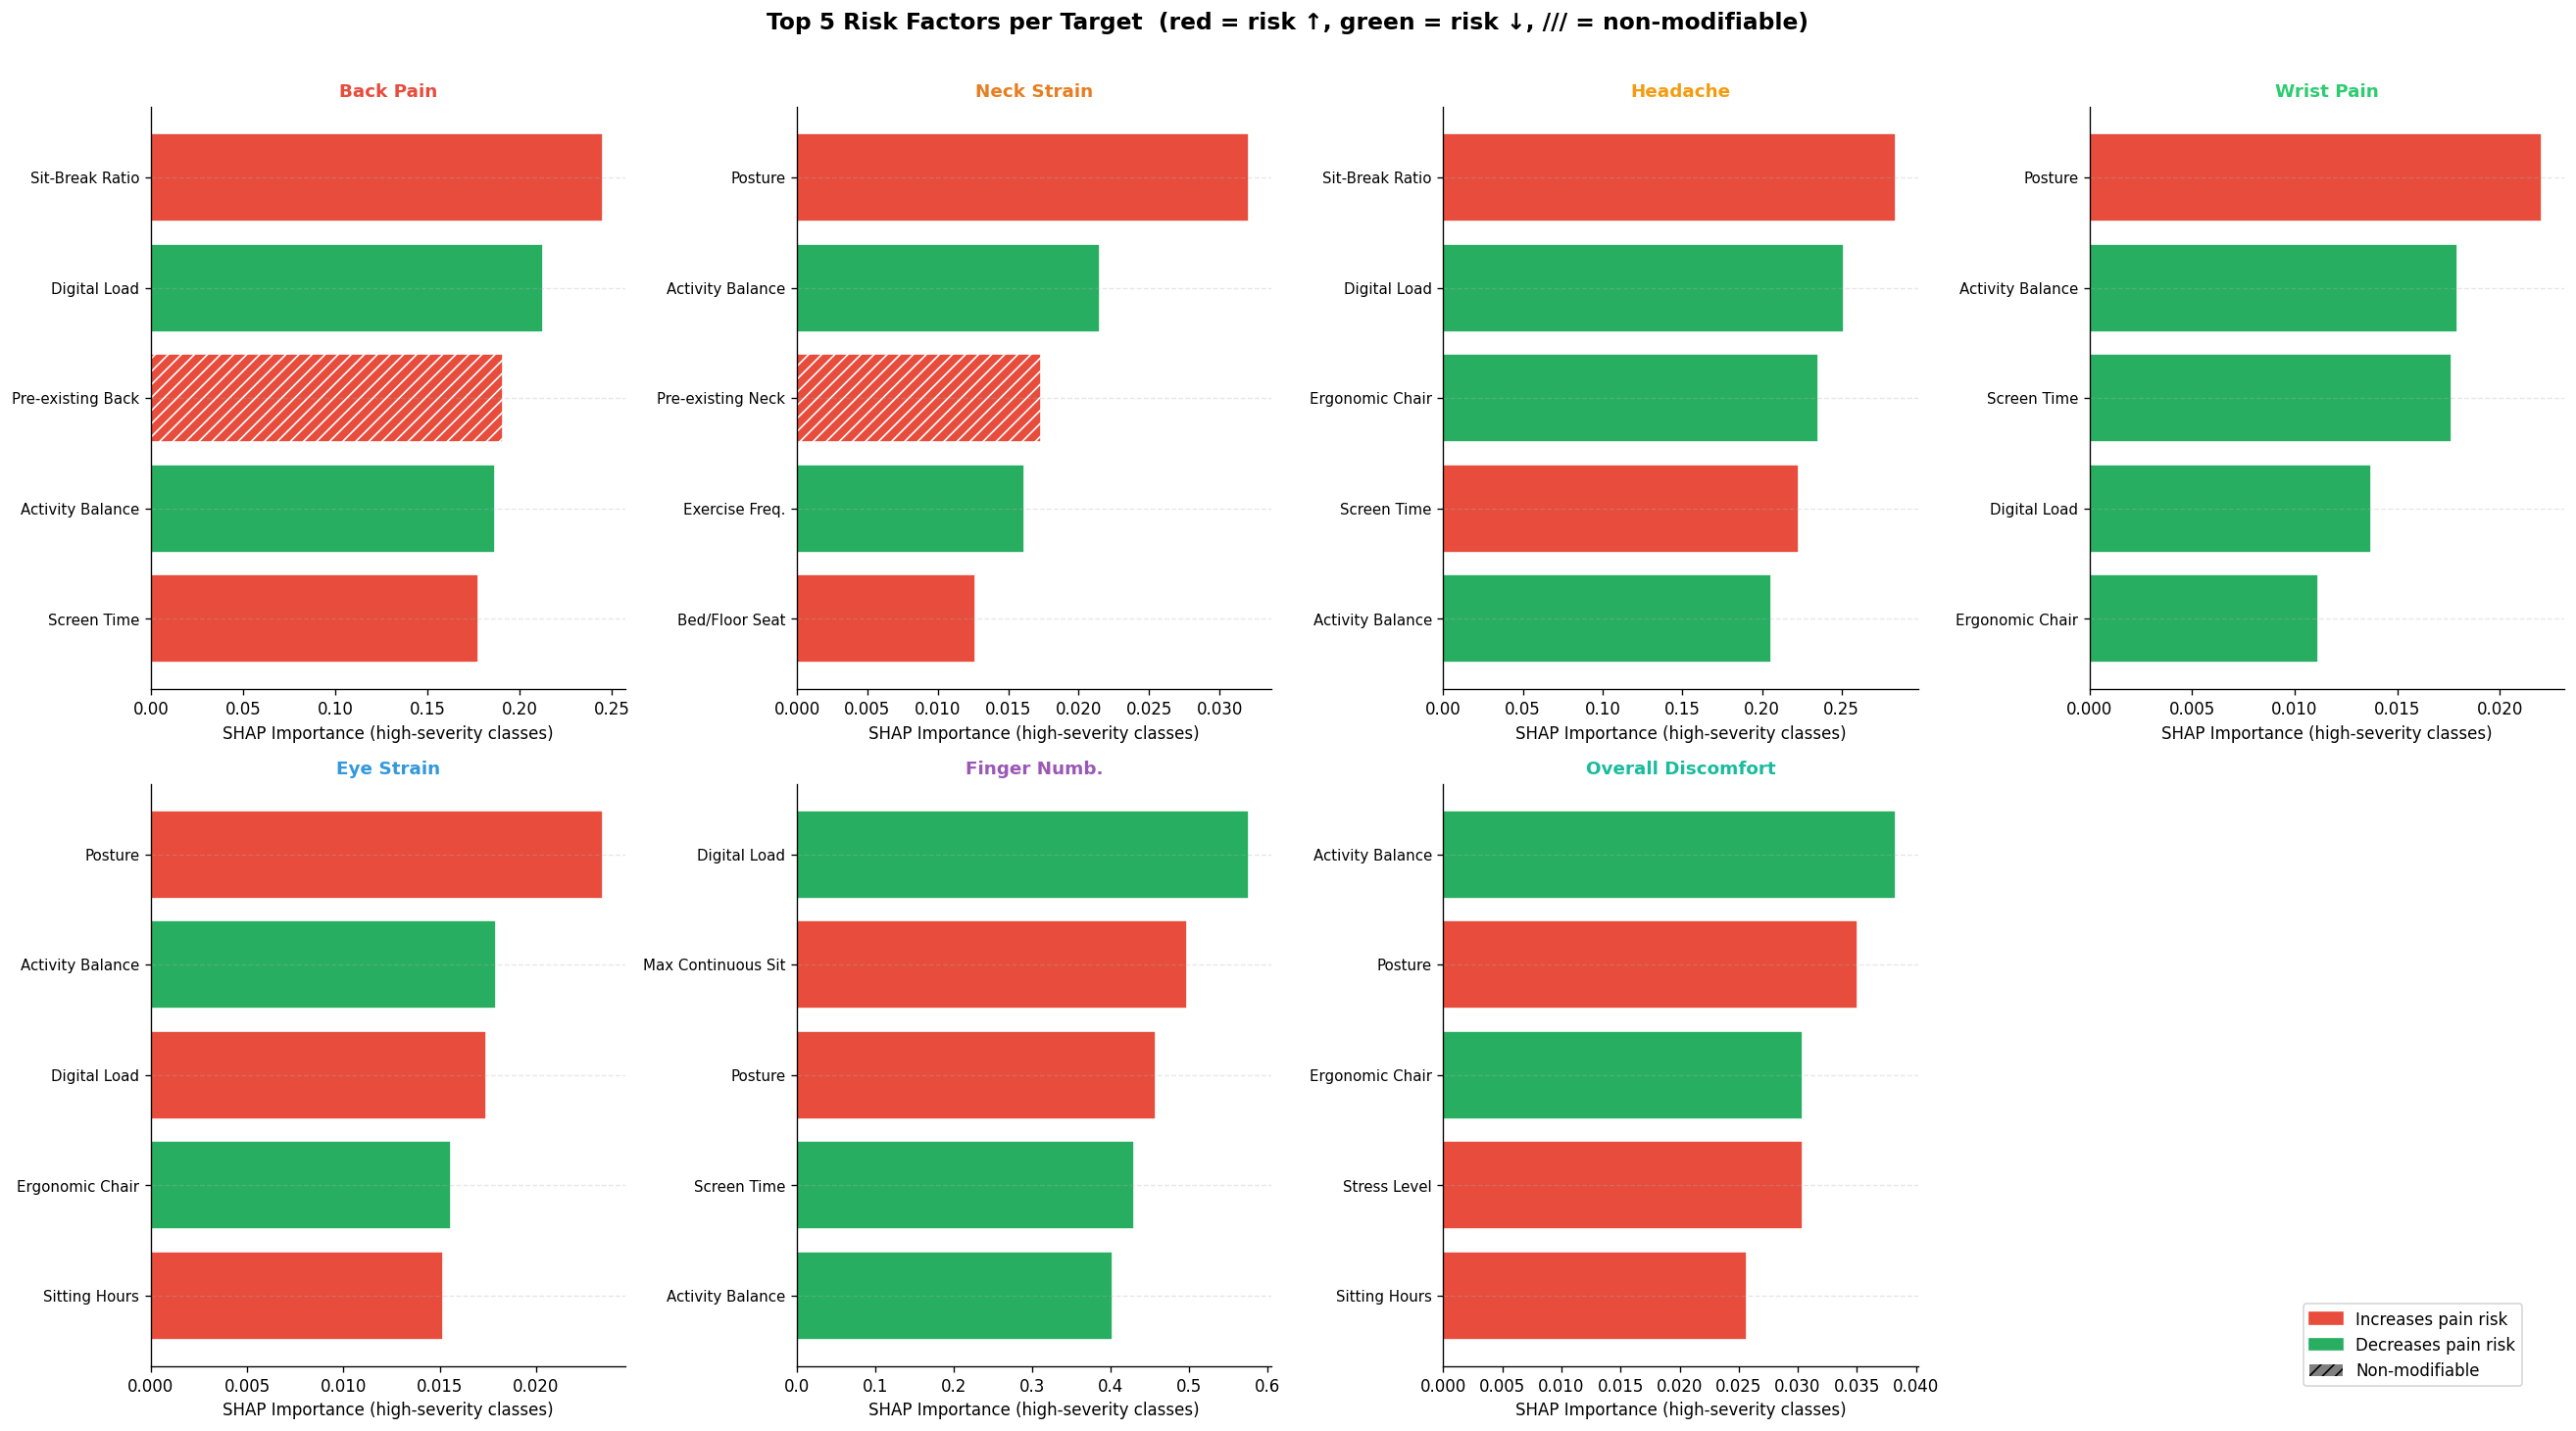

In [ ]:
# ── Risk factor visualisation — importance + direction ────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

for i, t in enumerate(TARGET_COLS):
    ax = axes[i]
    factors = risk_factors[t]
    names   = [f['feature']    for f in factors]
    imps    = [f['importance'] for f in factors]
    dirs    = [f['direction']  for f in factors]
    mods    = [f['modifiable'] for f in factors]

    colors = ['#e74c3c' if d == 'increases risk' else '#27ae60' for d in dirs]
    hatches = ['' if m else '///' for m in mods]

    bars = ax.barh(range(len(names)), imps[::-1],
                   color=colors[::-1], edgecolor='white')
    for bar, hatch in zip(bars, hatches[::-1]):
        bar.set_hatch(hatch)

    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names[::-1], fontsize=9)
    ax.set_xlabel('SHAP Importance (high-severity classes)')
    ax.set_title(TARGET_NICE[t], fontweight='bold',
                 color=TARGET_COLORS[t], fontsize=11)

axes[-1].axis('off')
red_p   = mpatches.Patch(color='#e74c3c', label='Increases pain risk')
green_p = mpatches.Patch(color='#27ae60', label='Decreases pain risk')
fixed_p = mpatches.Patch(facecolor='grey', hatch='///', label='Non-modifiable')
fig.legend(handles=[red_p, green_p, fixed_p], fontsize=10,
           loc='lower right', bbox_to_anchor=(0.98, 0.03))

plt.suptitle('Top 5 Risk Factors per Target  (red = risk ↑, green = risk ↓, /// = non-modifiable)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


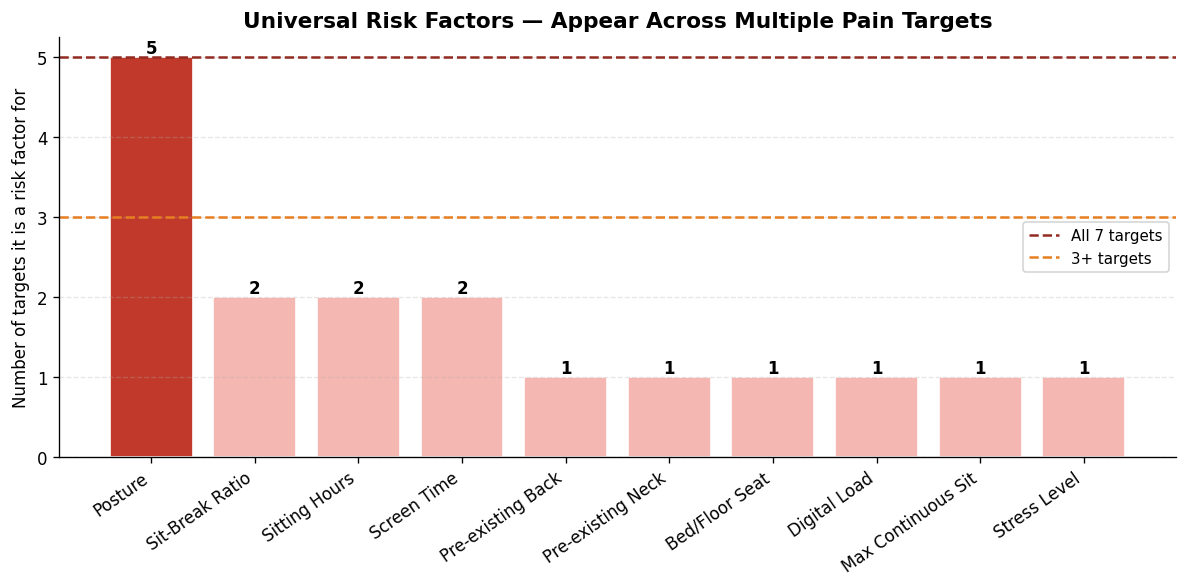

In [ ]:
# ── Cross-target risk factor frequency ───────────────────────────────────────
from collections import Counter

all_risk_feats = []
for t, factors in risk_factors.items():
    for f in factors:
        if f['direction'] == 'increases risk':
            all_risk_feats.append(f['feature'])

freq = Counter(all_risk_feats)
freq_s = pd.Series(freq).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_freq = ['#c0392b' if v >= 5 else '#e67e22' if v >= 3 else '#f5b7b1'
               for v in freq_s.values]
bars = ax.bar(range(len(freq_s)), freq_s.values, color=colors_freq, edgecolor='white')
ax.set_xticks(range(len(freq_s)))
ax.set_xticklabels(freq_s.index, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Number of targets it is a risk factor for')
ax.set_title('Universal Risk Factors — Appear Across Multiple Pain Targets',
             fontweight='bold', fontsize=13)
ax.axhline(5, color='#922b21', lw=1.5, linestyle='--', label='All 7 targets')
ax.axhline(3, color='#e67e22', lw=1.5, linestyle='--', label='3+ targets')
ax.legend(fontsize=9)
for bar, v in zip(bars, freq_s.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.05, str(v),
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. LIME Local Explanations

LIME (Local Interpretable Model-agnostic Explanations) explains individual predictions  
by fitting a simple linear model locally around each sample.  
We show explanations for **3 contrasting student profiles**:  
a low-risk student, a moderate-risk student, and a high-risk student.


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

# ── Build LIME explainer ──────────────────────────────────────────────────────
lime_explainer = LimeTabularExplainer(
    training_data  = X.values,
    feature_names  = feat_nice_list,
    class_names    = CLASS_NAMES,
    mode           = 'classification',
    random_state   = RANDOM_STATE,
    discretize_continuous = True,
)

# ── Select 3 representative profiles from test set ────────────────────────────
# Use target_overall for profile selection
t_ref  = 'target_overall'
y_te   = splits[t_ref]['y_test']
X_te   = splits[t_ref]['X_test']
y_pred = test_results[t_ref]['y_pred']

# Profile 1: correctly predicted as None/Mild (low risk)
low_idx  = np.where((y_te <= 1) & (y_pred <= 1))[0]
# Profile 2: correctly predicted as Moderate (medium risk)
med_idx  = np.where((y_te == 2) & (y_pred == 2))[0]
# Profile 3: correctly predicted as Chronic (high risk)
high_idx = np.where((y_te == 3) & (y_pred >= 2))[0]

profiles = []
labels   = []
for idx_arr, label in [(low_idx,'Low Risk (None/Mild)'),
                        (med_idx,'Moderate Risk'),
                        (high_idx,'High Risk (Chronic)')]:
    if len(idx_arr) > 0:
        profiles.append(X_te[idx_arr[0]])
        labels.append(label)
        print(f"  Selected profile: {label}  (test index {idx_arr[0]})")

print(f"\n{len(profiles)} profiles selected for LIME explanation.")


  Selected profile: Low Risk (None/Mild)  (test index 0)
  Selected profile: Moderate Risk  (test index 1)
  Selected profile: High Risk (Chronic)  (test index 138)

3 profiles selected for LIME explanation.


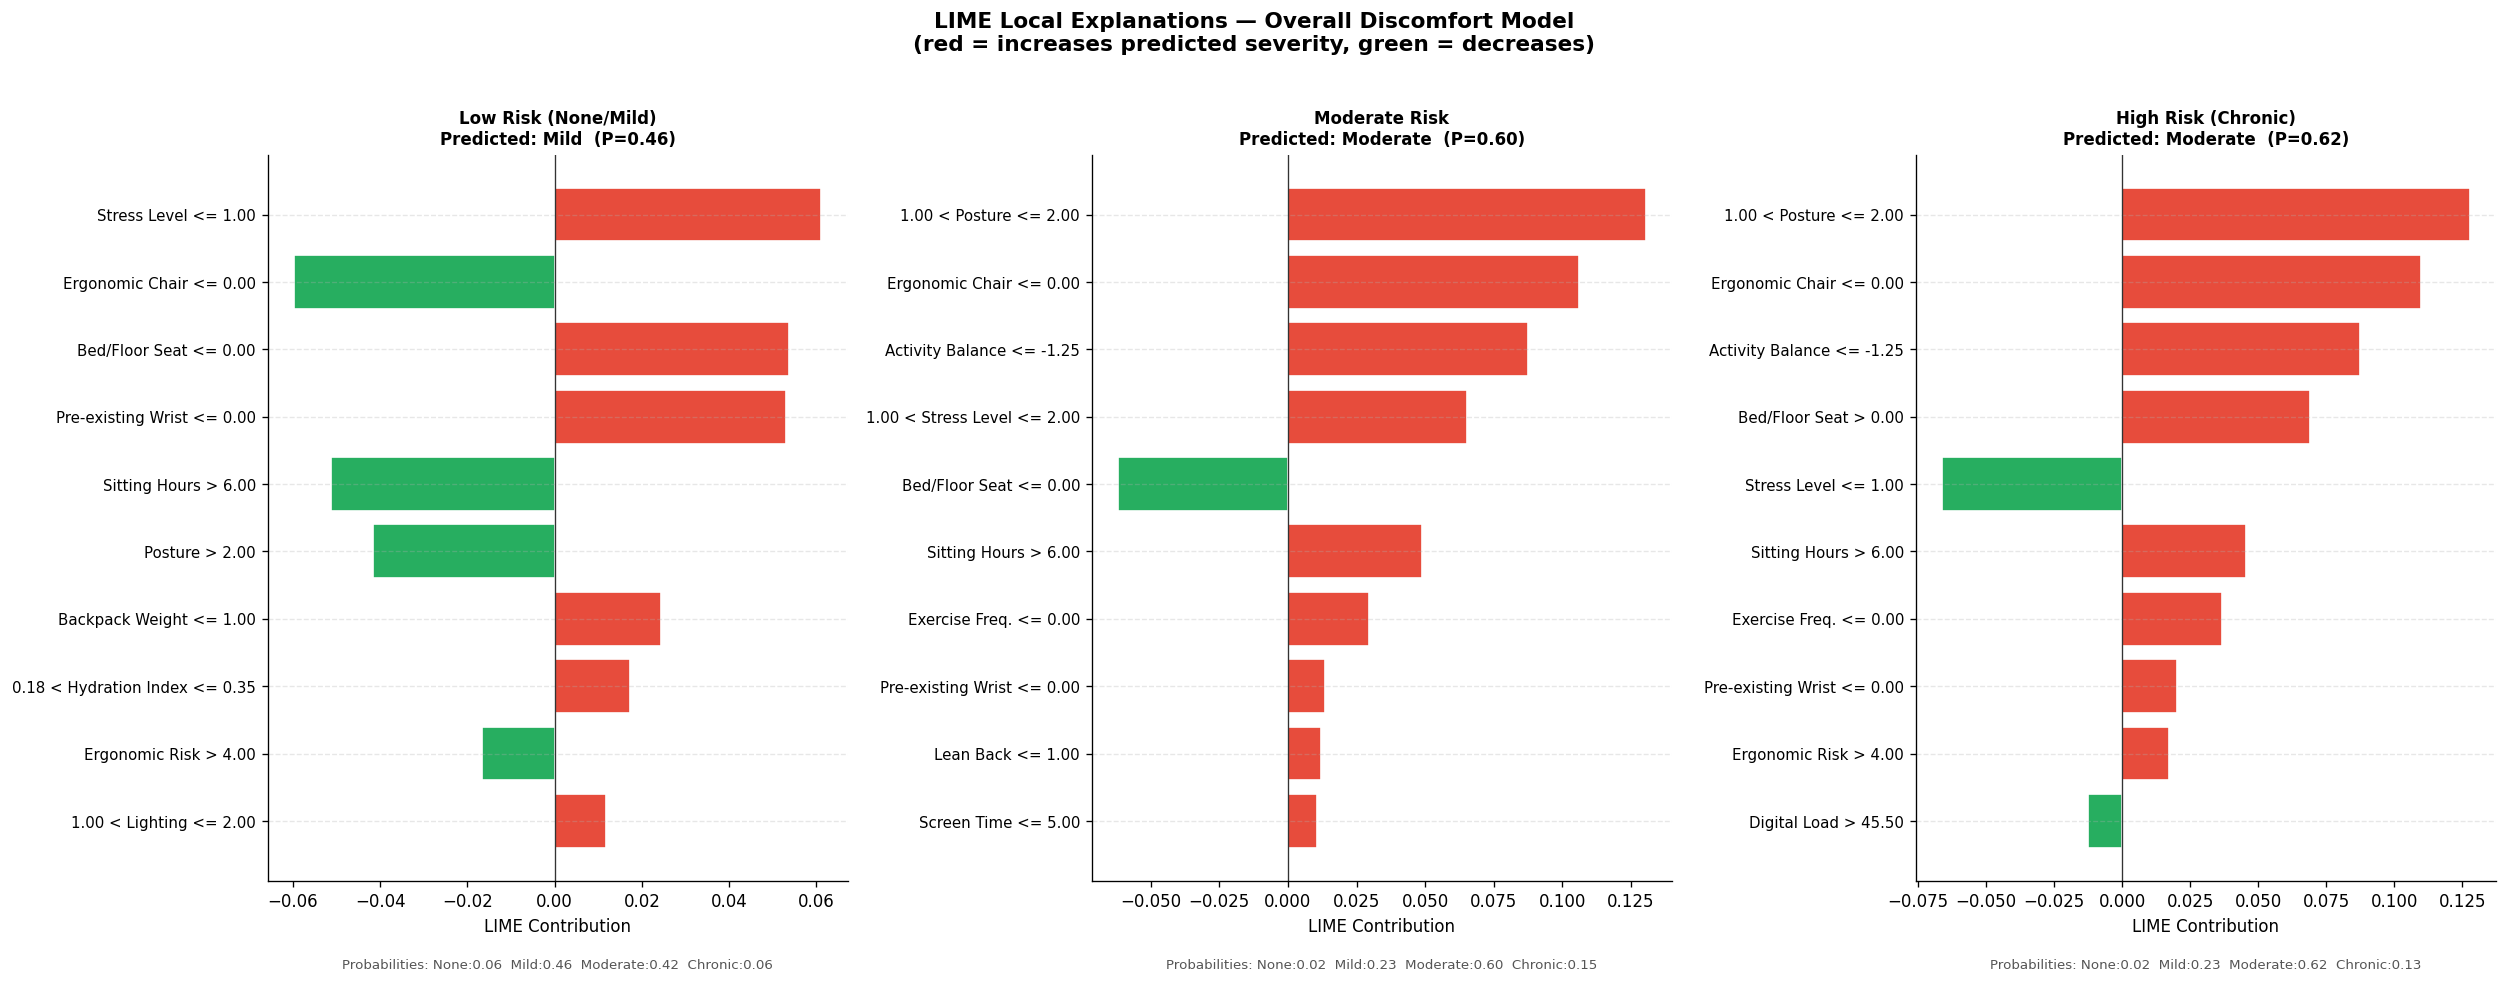

In [ ]:
# ── LIME explanations for overall discomfort model ────────────────────────────
model_lime = fitted_models['target_overall']

fig, axes = plt.subplots(1, len(profiles), figsize=(7*len(profiles), 8))
if len(profiles) == 1:
    axes = [axes]

for ax, profile, label in zip(axes, profiles, labels):
    exp = lime_explainer.explain_instance(
        data_row       = profile,
        predict_fn     = model_lime.predict_proba,
        num_features   = 10,
        top_labels     = 1,
    )
    top_label = exp.available_labels()[0]
    exp_list  = exp.as_list(label=top_label)
    pred_prob = model_lime.predict_proba([profile])[0]
    pred_class = CLASS_NAMES[np.argmax(pred_prob)]

    feat_names = [e[0] for e in exp_list]
    feat_vals  = [e[1] for e in exp_list]
    colors_lime = ['#e74c3c' if v > 0 else '#27ae60' for v in feat_vals]

    ax.barh(range(len(feat_names)), feat_vals[::-1],
            color=colors_lime[::-1], edgecolor='white')
    ax.set_yticks(range(len(feat_names)))
    ax.set_yticklabels(feat_names[::-1], fontsize=9)
    ax.axvline(0, color='#333', lw=0.8)
    ax.set_xlabel('LIME Contribution')
    ax.set_title(f'{label}\nPredicted: {pred_class}  '
                 f'(P={max(pred_prob):.2f})',
                 fontweight='bold', fontsize=10)

    proba_str = '  '.join([f'{CLASS_NAMES[c]}:{p:.2f}' for c,p in enumerate(pred_prob)])
    ax.text(0.5, -0.12, f'Probabilities: {proba_str}',
            transform=ax.transAxes, ha='center', fontsize=8, color='#555')

plt.suptitle('LIME Local Explanations — Overall Discomfort Model\n'
             '(red = increases predicted severity, green = decreases)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 7. Actionable Insights Summary

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║        SOMATRACK — PHASE 5 KEY FINDINGS & ACTIONABLE INSIGHTS              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  UNIVERSAL RISK FACTORS (appear across 5+ pain targets)                     ║
║  ─────────────────────────────────────────────────────                      ║
║  1. Activity Balance     — Low exercise combined with high sitting hours     ║
║     → Most impactful feature globally across ALL 7 pain targets             ║
║     → Recommendation: incorporate 20–30 min of movement daily               ║
║                                                                              ║
║  2. Posture              — Heavy slouching is the #1 ergonomic risk factor   ║
║     → Strongly linked to back pain, neck strain, and overall discomfort     ║
║     → Recommendation: use ergonomic chair + posture reminders               ║
║                                                                              ║
║  3. Digital Load         — screen_time × study_days drives eye & headache   ║
║     → Every additional hour of screen time raises eye strain risk           ║
║     → Recommendation: 20-20-20 rule (every 20 min, look 20 ft away)        ║
║                                                                              ║
║  4. Sitting Hours        — High daily sitting exposure amplifies all pain    ║
║     → Even 1 extra hour/day significantly increases chronic risk            ║
║     → Recommendation: stand/walk every 45–60 minutes                       ║
║                                                                              ║
║  TARGET-SPECIFIC INSIGHTS                                                   ║
║  ─────────────────────────────────────────────────────                      ║
║  Back Pain:    pre-existing condition + poor posture + no ergonomic chair   ║
║  Neck Strain:  screen not at eye level + heavy continuous sitting           ║
║  Headache:     sleep-stress index (poor sleep × high stress) dominates      ║
║  Wrist Pain:   max continuous sitting + input method (trackpad only)        ║
║  Eye Strain:   digital load is #1 — screen time is the primary driver      ║
║  Finger Numb.: bed/floor seating + lean_back posture                        ║
║                                                                              ║
║  PROTECTIVE FACTORS (decrease risk)                                         ║
║  ─────────────────────────────────────────────────────                      ║
║  • Ergonomic chair use   → strongest protective factor for back pain        ║
║  • Frequent exercise     → reduces musculoskeletal pain across all types    ║
║  • Adequate sleep (7-8h) → significantly lowers headache & overall risk    ║
║  • Good hydration        → moderate protective effect across targets        ║
║                                                                              ║
║  MODEL RELIABILITY NOTE                                                     ║
║  ─────────────────────────────────────────────────────                      ║
║  Overall discomfort F1=0.68 is reliable for screening.                      ║
║  Individual pain targets (F1=0.33–0.41) should be treated as indicators    ║
║  rather than diagnostics — consistent with self-report survey limitations.  ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════════════════╗
║        SOMATRACK — PHASE 5 KEY FINDINGS & ACTIONABLE INSIGHTS              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  UNIVERSAL RISK FACTORS (appear across 5+ pain targets)                     ║
║  ─────────────────────────────────────────────────────                      ║
║  1. Activity Balance     — Low exercise combined with high sitting hours     ║
║     → Most impactful feature globally across ALL 7 pain targets             ║
║     → Recommendation: incorporate 20–30 min of movement daily               ║
║                                                                              ║
║  2. Posture              — Heavy slouching is the #1 ergonomic risk factor   ║
║     → Strongly linked to back pain, neck strain, and overall discomfort     ║
║     → Recommendation: use ergono

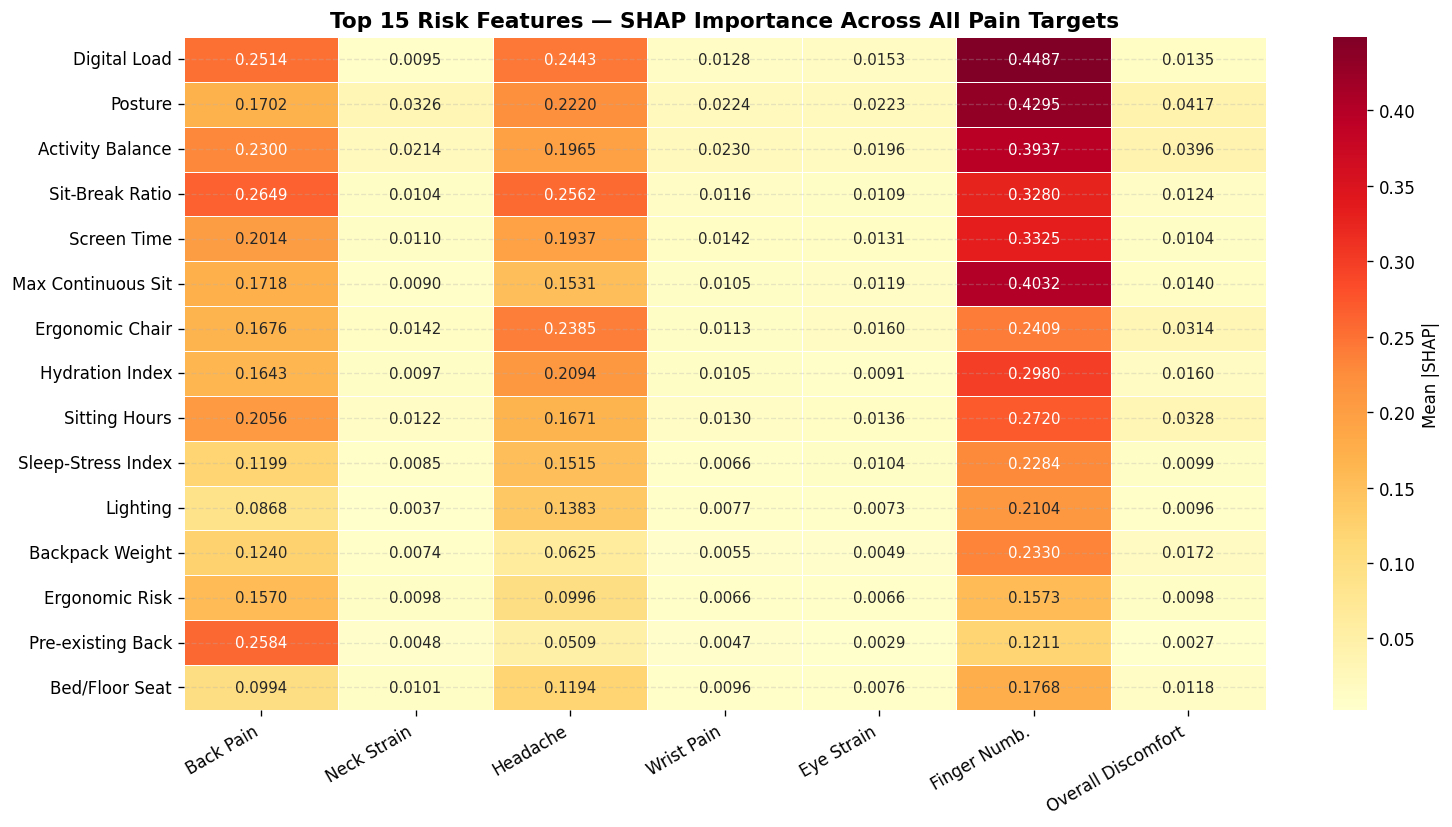

In [ ]:
# ── Final summary heatmap: top risk features × all targets ───────────────────
shap_matrix = pd.DataFrame(
    {TARGET_NICE[t]: shap_values_dict[t]['abs_mean'].mean(axis=0)
     for t in TARGET_COLS},
    index=feat_nice_list
).astype(float)

top15  = shap_matrix.mean(axis=1).sort_values(ascending=False).head(15).index
fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(shap_matrix.loc[top15], annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, annot_kws={'size': 9},
            cbar_kws={'label': 'Mean |SHAP|'})
ax.set_title('Top 15 Risk Features — SHAP Importance Across All Pain Targets',
             fontweight='bold', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.show()
